# Hybrid model for pneumonia detection
## 1. Setup
### 1.1. Installing dependencies

In [1]:
!pip install pennylane scikit-learn numpy scipy matplotlib pandas pennylane-qiskit kagglehub scikit-image seaborn opencv-python torch torchvision pennylane-lightning-gpu optuna

In [2]:
from dataclasses import dataclass
import torch
import numpy as np
import random
import os
import math

@dataclass
class ExperimentConfig:
    # Experiment Metadata
    project_name: str = "Hybrid_ResNet50_QNN_Pneumonia"
    seed: int = 6
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Data Paths
    data_root: str = "/home/mforgo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/"
    output_dir: str = "./results"
    
    # Classical Backbone
    backbone_name: str = "resnet50"  # Fixed naming consistencyd
    feature_dim: int = 2048          # 2048 for ResNet50

    # Preprocessing
    reduction_method: str = "pca"    # 'pca', 'lda' or 'selectkbest'
    target_dims: int = 64             # Dimensionality after reduction
    
    # Quantum Components
    n_qubits: int = math.ceil(math.log2(target_dims))                # Determined by PCA components
    n_layers: int = 3
    encoding_method: str = "amplitude" # 'amplitude' or 'angle'
    
    # Training Hyperparams
    batch_size: int = 32
    learning_rate: float = 0.001
    epochs: int = 30
    patience: int = 5
    min_learning_rate: float = 1e-5
    warmup_epochs: int = 3

    nlayers_per_block: int = 3  # NEW: QDNN depth
    n_quantum_blocks: int = 2   # NEW: Stacked quantum layers

    

def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Global seed set to {seed}")

CFG = ExperimentConfig()
seed_everything(CFG.seed)
os.makedirs(CFG.output_dir, exist_ok=True)


🔒 Global seed set to 6


In [3]:
import os
import kagglehub

# Desired root directory of the dataset
expected_root = os.path.join(".", "chest_xray")

if os.path.isdir(expected_root) and os.listdir(expected_root):
    # Use existing local copy
    CFG.data_root = os.path.abspath(expected_root) + "/"
    print("✅ Using existing dataset at:", CFG.data_root)
else:
    # Download latest version via kagglehub (cached under ~/.cache/kagglehub) [web:33][web:37]
    path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    CFG.data_root = os.path.join(path, "chest_xray") + "/"
    print("⬇️ Downloaded dataset. Path to files:", CFG.data_root)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
⬇️ Downloaded dataset. Path to files: /kaggle/input/chest-xray-pneumonia/chest_xray/


## 2. Hybrid model
### 2.1. Classical preprocessing

In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import os

def get_transforms(img_size=224):
    """
    Standard ImageNet normalization. 
    Using standard stats ensures the pre-trained ResNet works as intended.
    """
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_dataloaders(config):
    """
    Creates DataLoaders for Train/Test/Val using ImageFolder.
    This replaces manual os.listdir loops.
    """
    loaders = {}
    sets = ['train', 'test', 'val']
    
    print(f"📂 Loading data from: {config.data_root}")
    
    for split in sets:
        path = os.path.join(config.data_root, split)
        if not os.path.exists(path):
            print(f"⚠️ Warning: Split '{split}' not found at {path}")
            continue
            
        # ImageFolder automatically handles class labels based on folder names
        dataset = datasets.ImageFolder(root=path, transform=get_transforms())
        
        loaders[split] = DataLoader(
            dataset, 
            batch_size=config.batch_size, 
            shuffle=False, # Important: Keep False to match features with filenames later
            num_workers=2, # Parallel loading
            pin_memory=True
        )
        print(f"   • {split.upper()}: Found {len(dataset)} images")
        
    return loaders

class FeatureExtractor(nn.Module):
    """
    Wraps ResNet50 to output raw features instead of classification scores.
    """
    def __init__(self):
        super().__init__()
        # Load modern V2 weights for better performance
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        self.backbone = models.resnet50(weights=weights)
        
        # Replace the final classification layer (fc) with Identity
        # This allows us to get the 2048 feature vector directly
        self.backbone.fc = nn.Identity()
        self.backbone.eval() # Set to evaluation mode (freezes BatchNorm)
        
    def forward(self, x):
        return self.backbone(x)

def run_feature_extraction(config):
    """
    The Engine: Loads data, passes it through ResNet, and saves features.
    """
    device = torch.device(config.device)
    model = FeatureExtractor().to(device)
    loaders = get_dataloaders(config)
    
    # Create directory for saved features
    save_dir = os.path.join(config.output_dir, "features")
    os.makedirs(save_dir, exist_ok=True)
    
    metadata = []
    
    print(f"\n🚀 Starting extraction with {config.backbone_name} on {device}...")
    
    with torch.no_grad(): # Disable gradient calculation for speed
        for split, loader in loaders.items():
            
            for batch_idx, (images, labels) in enumerate(tqdm(loader, desc=f"Extracting {split}")):
                images = images.to(device)
                
                # Forward pass: Get features (Batch_Size, 2048)
                with torch.amp.autocast(config.device):  # Mixed precision for speed
                    features = model(images)
                
                features = model(images).cpu().numpy()
                # Match features back to original filenames
                # We calculate the global index based on batch size
                start_idx = batch_idx * config.batch_size
                
                for i, feat in enumerate(features):
                    global_idx = start_idx + i
                    # Retrieve path from dataset.samples which is [(path, class_idx), ...]
                    original_path, label_idx = loader.dataset.samples[global_idx]
                    filename = os.path.basename(original_path)
                    classname = loader.dataset.classes[label_idx]
                    
                    # Save individual feature file
                    save_name = f"{split}_{classname}_{filename}.npy"
                    save_path = os.path.join(save_dir, save_name)
                    np.save(save_path, feat)
                    
                    metadata.append({
                        'feature_path': save_path,
                        'label': label_idx, # 0 or 1
                        'classname': classname,
                        'split': split,
                        'original_path': original_path
                    })
    
    # Save metadata CSV for easy loading later
    meta_path = os.path.join(config.output_dir, "metadata.csv")
    pd.DataFrame(metadata).to_csv(meta_path, index=False)
    print(f"✅ Extraction complete. Metadata saved to {meta_path}")
    return meta_path

# Execute the pipeline using our Config
meta_csv_path = run_feature_extraction(CFG)

📂 Loading data from: /kaggle/input/chest-xray-pneumonia/chest_xray/
   • TRAIN: Found 5216 images
   • TEST: Found 624 images
   • VAL: Found 16 images

🚀 Starting extraction with resnet50 on cuda...


Extracting train:   0%|          | 0/163 [00:00<?, ?it/s]

Extracting test:   0%|          | 0/20 [00:00<?, ?it/s]

Extracting val:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Extraction complete. Metadata saved to ./results/metadata.csv


In [5]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split  
import joblib
import os

def load_features(config):
    """
    Loads features from .npy files based on the metadata CSV.
    """
    meta_path = os.path.join(config.output_dir, "metadata.csv")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Metadata CSV not found at {meta_path}. Run Step 3 first.")
    
    df = pd.read_csv(meta_path)
    splits = ['train', 'val', 'test']
    
    X, y = {}, {}
    
    print(f"📂 Loading raw features...")
    for split in splits:
        subset = df[df['split'] == split]
        features = [np.load(path) for path in subset['feature_path']]
        X[split] = np.vstack(features)
        y[split] = subset['label'].values
    
    return X, y

def fix_validation_split(X, y, config):
    """
    OPRAVA: Sloučí Train (5216) a Val (16) a vytvoří nové rozdělení 80/20.
    Tím získáme cca 1000 validačních snímků místo 16.
    """
    print("\n⚠️ Fixing small validation set issue...")
    
    # 1. Sloučení
    X_combined = np.concatenate([X['train'], X['val']])
    y_combined = np.concatenate([y['train'], y['val']])
    
    # 2. Nové rozdělení (stratify zajistí správný poměr tříd)
    X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
        X_combined, y_combined, 
        test_size=0.2, 
        stratify=y_combined, 
        random_state=config.seed
    )
    
    # 3. Aktualizace slovníků
    X['train'], y['train'] = X_train_new, y_train_new
    X['val'], y['val']     = X_val_new, y_val_new
    
    print(f"   Original Val size: 16 -> New Val size: {len(X_val_new)}")
    print(f"   New Train size:    {len(X_train_new)}")

    # Class balance check
    for split in ['train', 'val', 'test']:
        pneumonia_pct = np.mean(y[split] == 1) * 100
        print(f"{split}: {pneumonia_pct:.1f}% pneumonia")

    return X, y

def build_pipeline(config):
    steps = [('scaler', StandardScaler())]
    
    if config.reduction_method == 'pca':
        steps.append(('reducer', PCA(n_components=config.target_dims, random_state=config.seed)))
    elif config.reduction_method == 'selectkbest':
        steps.append(('reducer', SelectKBest(score_func=f_classif, k=config.target_dims)))
    elif config.reduction_method == 'lda':
        steps.append(('reducer', LDA(n_components=min(config.target_dims, 1))))
    
    if config.encoding_method == 'amplitude':
        steps.append(('normalizer', Normalizer(norm='l2')))
    elif config.encoding_method == 'angle':
        steps.append(('minmax', MinMaxScaler(feature_range=(0, np.pi))))
        
    return Pipeline(steps)

def run_classical_preprocessing(config):
    # 1. Load Data
    X, y = load_features(config)
    
    # 2. FIX DATA SPLIT (Tohle je ta klíčová oprava)
    X, y = fix_validation_split(X, y, config)
    
    # 3. Build & Fit Pipeline
    pipeline = build_pipeline(config)
    print(f"\n🔄 Fitting {config.reduction_method.upper()} Pipeline...")
    
    pipeline.fit(X['train'], y['train'])
    
    # 4. Transform & Save
    X_processed = {
        'train': pipeline.transform(X['train']),
        'val':   pipeline.transform(X['val']),
        'test':  pipeline.transform(X['test'])
    }
    
    processed_dir = os.path.join(config.output_dir, "processed_data")
    os.makedirs(processed_dir, exist_ok=True)
    
    for split in ['train', 'val', 'test']:
        np.save(os.path.join(processed_dir, f"X_{split}.npy"), X_processed[split])
        np.save(os.path.join(processed_dir, f"y_{split}.npy"), y[split])
        
    pipeline_path = os.path.join(config.output_dir, "preprocessing_pipeline.joblib")
    joblib.dump(pipeline, pipeline_path)
    
    print(f"✅ Preprocessing complete. Data ready for Quantum Training.")
    return X_processed, y

# Spuštění opraveného kroku
X_data, y_data = run_classical_preprocessing(CFG)

📂 Loading raw features...

⚠️ Fixing small validation set issue...
   Original Val size: 16 -> New Val size: 1047
   New Train size:    4185
train: 74.2% pneumonia
val: 74.2% pneumonia
test: 62.5% pneumonia

🔄 Fitting PCA Pipeline...
✅ Preprocessing complete. Data ready for Quantum Training.


## Baseline

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import time

# --- 1. Definice Klasické Architektury ---
class ClassicalBaseline(nn.Module):
    def __init__(self, feature_dim=2048):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        # Sigmoid pro pravděpodobnost (0 až 1)
        return torch.sigmoid(self.classifier(x))

# --- 2. Trénovací Engine ---
def train_classical_model(config, X_data, y_data):
    print(f"\n🧠 Inicializace klasického modelu (Vstupní příznaky: {X_data['train'].shape[1]})...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"   Zařízení: {device}")

    # Převod dat na PyTorch Tensory
    train_ds = TensorDataset(torch.FloatTensor(X_data['train']), torch.FloatTensor(y_data['train']))
    val_ds = TensorDataset(torch.FloatTensor(X_data['val']), torch.FloatTensor(y_data['val']))
    
    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config.batch_size)

    # Inicializace modelu
    model = ClassicalBaseline(feature_dim=X_data['train'].shape[1]).to(device)
    
    # Optimizer a Scheduler (zachování parametrů z kvantového modelu)
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    
    # Loss funkce s vážením (BCELoss s manuálním vážením vzorků)
    criterion = nn.BCELoss(reduction='none')

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_state = None
    
    start_time = time.time()

    for epoch in range(config.epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device).view(-1, 1)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            # Váha 3.0 pro Normal (0), váha 1.0 pro Pneumonie (1)
            batch_weights = torch.where(batch_y == 0, 3.0, 1.0)
            
            raw_loss = criterion(outputs, batch_y)
            loss = (raw_loss * batch_weights).mean()
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        avg_train_loss = epoch_loss / len(train_loader)

        # Validace
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device).view(-1, 1)
                outputs = model(batch_X)
                
                v_weights = torch.where(batch_y == 0, 3.0, 1.0)
                v_loss = (criterion(outputs, batch_y) * v_weights).mean()
                val_loss += v_loss.item()
                
                preds = (outputs > 0.5).float()
                correct += (preds == batch_y).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / len(y_data['val'])
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:02d}: Train Loss {avg_train_loss:.4f} | Val Acc {val_acc:.4f}")

        # Early stopping logika
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= config.patience:
            print(f"⏹ Early stopping v epoše {epoch+1}")
            break

    print(f"✅ Trénování dokončeno za {time.time() - start_time:.1f}s.")
    model.load_state_dict(best_model_state)
    return model, history

# --- 3. Evaluační Funkce ---
def evaluate_classical_model(model, X_test, y_test):
    print("\n📊 Vyhodnocení na testovacím setu...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)
        probs = model(X_tensor).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'f1_score': f1_score(y_test, preds, average='macro'),
        'auc_score': roc_auc_score(y_test, probs)
    }
    
    print(f"   Test Accuracy: {metrics['accuracy']:.2%}")
    print(f"   Test F1 Score: {metrics['f1_score']:.4f}")
    print(f"   Test AUC:      {metrics['auc_score']:.4f}")
    return metrics, preds, probs

# --- 4. Spuštění ---
# Předpokládá existující CFG, X_data a y_data z tvého notebooku
#best_model, history = train_classical_model(CFG, X_data, y_data)
#test_metrics, test_preds, test_probs = evaluate_classical_model(best_model, X_data['test'], y_data['test'])

## Quantum extractor


📐 QDNN ARCHITECTURE VISUALIZATION

🔷 Single Quantum Block Structure:

   Step 1: AmplitudeEmbedding (64D → 6 qubits)
   │
   ├─ Layer 1:
   │  ├─ Rot(θ,φ,ω) on all 6 qubits  [Trainable rotations]
   │  ├─ 15 CNOT gates (dense entanglement)
   │  └─ RZ(λ) on all 6 qubits  [Skip connections]
   ├─ Layer 2:
   │  ├─ Rot(θ,φ,ω) on all 6 qubits  [Trainable rotations]
   │  ├─ 15 CNOT gates (dense entanglement)
   │  └─ RZ(λ) on all 6 qubits  [Skip connections]
   ├─ Layer 3:
   │  ├─ Rot(θ,φ,ω) on all 6 qubits  [Trainable rotations]
   │  ├─ 15 CNOT gates (dense entanglement)
   │
   └─ Measure: PauliZ on all 6 qubits → 6 expectation values



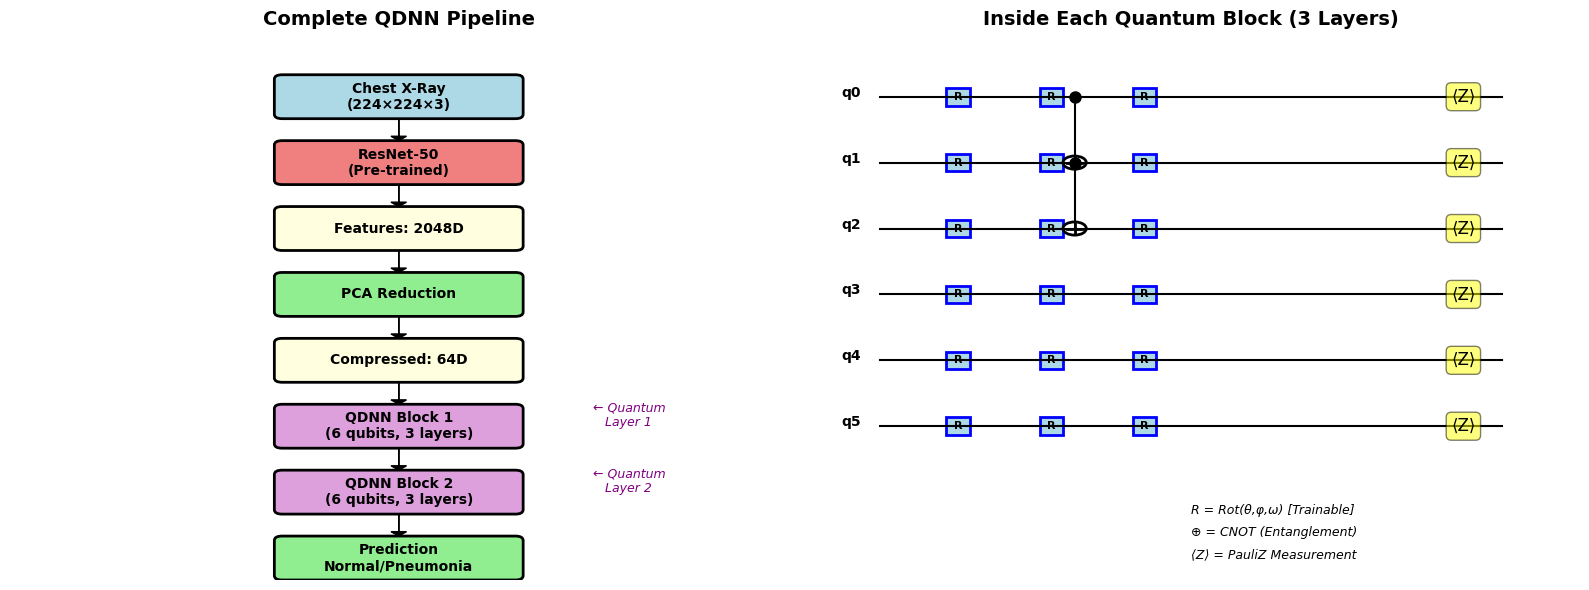


🔹 QDNN CONFIGURATION SUMMARY:
   Quantum Parameters:
      • Number of Qubits:          6
      • Layers per Block:          3
      • Number of Blocks:          2 (stacked)
      • Feature Dimension:         64D → 64 amplitudes

   Circuit Architecture:
      • Entanglement Pattern:      Dense (all-to-all)
      • CNOTs per Layer:           15
      • Rot Gates per Layer:       6 × 3 params = 18
      • RZ Gates (skip conn):      12

   Trainable Parameters:
      • Block 1:                   72 angles
      • Block 2:                   72 angles
      • TOTAL:                     144 parameters

   Circuit Complexity:
      • Gates per Layer:           27 ≈ 27
      • Total Depth (1 block):     ~81 gates
      • Both Blocks Combined:      ~162 gates

🔄 Data Flow Path:
   ResNet Features (64D)
      ↓ [AmplitudeEmbedding]
   Quantum State |ψ₁⟩ (6 qubits)
      ↓ [Block 1: 3 Layers]
   Measurements → 6 values ∈ [-1, +1]
      ↓ [Pool & Re-embed]
   Quantum State |ψ₂⟩ (6 qubits)
      

Epoch 1/30:   0%|          | 0/130 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/autograd/tracer.py:16: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


   Epoch 1: Train Loss 1.7617 | Val Loss 1.6634 | Val Acc 0.5950 | LR 0.000333


Epoch 2/30:   0%|          | 0/130 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/autograd/tracer.py:16: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


   Epoch 2: Train Loss 1.7634 | Val Loss 1.6634 | Val Acc 0.5950 | LR 0.000667


Epoch 3/30:   0%|          | 0/130 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/autograd/tracer.py:16: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


KeyboardInterrupt: 

In [7]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pennylane.numpy as pnp

class CosineAnnealingScheduler:
    """Smooth cosine annealing schedule instead of manual steps."""
    def __init__(self, initial_lr=0.002, min_lr=0.0001, epochs=50, warmup_epochs=2):
        self.initial_lr = initial_lr
        self.min_lr = min_lr
        self.epochs = epochs
        self.warmup_epochs = warmup_epochs

    def get_lr(self, epoch):
        """Compute learning rate for given epoch."""
        if epoch < self.warmup_epochs:
            return self.initial_lr * (epoch + 1) / self.warmup_epochs
        progress = (epoch - self.warmup_epochs) / (self.epochs - self.warmup_epochs)
        return self.min_lr + (self.initial_lr - self.min_lr) * (1 + math.cos(math.pi * progress)) / 2

    def step(self, optimizer, epoch):
        """Update optimizer's learning rate."""
        lr = self.get_lr(epoch)
        optimizer.stepsize = lr
        return lr

class QDNN_Pneumonia(nn.Module):
    """Complete QDNN for your pneumonia project - DROP-IN REPLACEMENT"""
    
    def __init__(self, feature_dim=64, n_qubits=6):
        super().__init__()
        self.n_qubits = n_qubits
        
        # Two quantum devices for stacked layers
        self.dev1 = qml.device("lightning.gpu", wires=n_qubits)
        self.dev2 = qml.device("lightning.gpu", wires=n_qubits)
        
        # Quantum Conv Block 1
        self.qconv1 = self._make_qconv_block(self.dev1)
        # Quantum Conv Block 2  
        self.qconv2 = self._make_qconv_block(self.dev2)
        
        # Classical final classifier (measurements → prediction)
        self.classifier = nn.Sequential(
            nn.Linear(2, 32),  # 2 quantum blocks → 32
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Initialize quantum weights
        self.reset_parameters()
    
    def _make_qconv_block(self, dev):
        """3-layer quantum conv block"""
        @qml.qnode(dev, interface="torch", diff_method="adjoint")
        def qconv(inputs, weights):
            # Amplitude embedding (your current method!)
            qml.AmplitudeEmbedding(inputs, wires=range(self.n_qubits), 
                                 normalize=True, pad_with=0.)
            
            # 3-layer deep quantum circuit
            for layer in range(3):
                # Rotations
                for w in range(self.n_qubits):
                    qml.Rot(weights[layer, w, 0], 
                           weights[layer, w, 1], 
                           weights[layer, w, 2], wires=w)
                
                # DENSE entanglement (QDNN magic!)
                for i in range(self.n_qubits):
                    for j in range(i+1, self.n_qubits):
                        qml.CNOT(wires=[i, j])
                
                # Skip connection
                if layer < 2:
                    for w in range(self.n_qubits):
                        qml.RZ(weights[layer, w, 3], wires=w)
            
            # Measure expectation values
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]
        
        return qconv
    
    def reset_parameters(self):
        """Initialize quantum weights"""
        for module in self.modules():
            if isinstance(module, qml.QNode):
                # Random init [-pi/2, pi/2]
                with torch.no_grad():
                    shape = module.weights.shape
                    module.weights.data = (torch.rand(shape) - 0.5) * np.pi
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Quantum Block 1: Features → Quantum measurements
        q1_out = self.qconv1(x, self.qconv1.weights)  # (batch, 6)
        
        # Quantum Block 2: Re-process quantum outputs!
        q1_mean = q1_out.mean(dim=1, keepdim=True)  # (batch, 1)
        q2_out = self.qconv2(q1_mean.repeat(1, self.n_qubits), 
                           self.qconv2.weights)  # (batch, 6)
        
        # Pool quantum features
        q_features = torch.stack([q1_out.mean(dim=1), q2_out.mean(dim=1)], dim=1)  # (batch, 2)
        
        # Classical classification
        return self.classifier(q_features).squeeze(-1)
    
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_qdnn(config):
    """Display QDNN architecture diagrams before training"""
    print("\n" + "="*70)
    print("📐 QDNN ARCHITECTURE VISUALIZATION")
    print("="*70 + "\n")
    
    n_qubits = config.n_qubits
    
    # 1. TEXT-BASED CIRCUIT DIAGRAM (Always works!)
    print("🔷 Single Quantum Block Structure:\n")
    print(f"   Step 1: AmplitudeEmbedding (64D → {n_qubits} qubits)")
    print(f"   │")
    for layer in range(config.n_layers):
        print(f"   ├─ Layer {layer+1}:")
        print(f"   │  ├─ Rot(θ,φ,ω) on all {n_qubits} qubits  [Trainable rotations]")
        print(f"   │  ├─ {n_qubits*(n_qubits-1)//2} CNOT gates (dense entanglement)")
        if layer < config.n_layers - 1:
            print(f"   │  └─ RZ(λ) on all {n_qubits} qubits  [Skip connections]")
        else:
            print(f"   │")
    print(f"   └─ Measure: PauliZ on all {n_qubits} qubits → {n_qubits} expectation values\n")
    
    # 2. ARCHITECTURE FLOWCHART
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Full pipeline
    ax1.axis('off')
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 12)
    ax1.set_title("Complete QDNN Pipeline", fontsize=14, fontweight='bold', pad=20)
    
    # Draw pipeline boxes
    boxes = [
        (5, 11, "Chest X-Ray\n(224×224×3)", 'lightblue'),
        (5, 9.5, "ResNet-50\n(Pre-trained)", 'lightcoral'),
        (5, 8, "Features: 2048D", 'lightyellow'),
        (5, 6.5, "PCA Reduction", 'lightgreen'),
        (5, 5, "Compressed: 64D", 'lightyellow'),
        (5, 3.5, f"QDNN Block 1\n({n_qubits} qubits, {config.n_layers} layers)", 'plum'),
        (5, 2, f"QDNN Block 2\n({n_qubits} qubits, {config.n_layers} layers)", 'plum'),
        (5, 0.5, "Prediction\nNormal/Pneumonia", 'lightgreen'),
    ]
    
    for x, y, text, color in boxes:
        box = mpatches.FancyBboxPatch((x-1.5, y-0.4), 3, 0.8, 
                                      boxstyle="round,pad=0.1", 
                                      edgecolor='black', facecolor=color, linewidth=2)
        ax1.add_patch(box)
        ax1.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Draw arrows between boxes
        if y > 0.9:
            ax1.arrow(x, y-0.5, 0, -0.4, head_width=0.2, head_length=0.1, fc='black', ec='black')
    
    # Add annotations
    ax1.text(7.5, 3.5, '← Quantum\n   Layer 1', fontsize=9, style='italic', color='purple')
    ax1.text(7.5, 2, '← Quantum\n   Layer 2', fontsize=9, style='italic', color='purple')
    
    # Right plot: Quantum block details
    ax2.axis('off')
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 12)
    ax2.set_title(f"Inside Each Quantum Block ({config.n_layers} Layers)", fontsize=14, fontweight='bold', pad=20)
    
    # Draw quantum operations
    y_start = 11
    for i in range(n_qubits):
        # Qubit wire
        ax2.plot([1, 9], [y_start - i*1.5, y_start - i*1.5], 'k-', linewidth=1.5)
        ax2.text(0.5, y_start - i*1.5, f'q{i}', fontsize=10, fontweight='bold')
        
        # Gates on each qubit
        x_pos = 2
        for layer in range(min(config.n_layers, 3)):  # Show max 3 layers
            # Rot gate
            rect = mpatches.Rectangle((x_pos-0.15, y_start - i*1.5 - 0.2), 0.3, 0.4,
                                     edgecolor='blue', facecolor='lightblue', linewidth=2)
            ax2.add_patch(rect)
            ax2.text(x_pos, y_start - i*1.5, 'R', fontsize=8, ha='center', va='center', fontweight='bold')
            x_pos += 1.2
    
    # Draw CNOT entanglement (示例)
    for i in range(min(2, n_qubits-1)):
        x_cnot = 3.5
        y1 = y_start - i*1.5
        y2 = y_start - (i+1)*1.5
        # Control
        ax2.plot(x_cnot, y1, 'ko', markersize=8)
        # Target
        ax2.add_patch(mpatches.Circle((x_cnot, y2), 0.15, edgecolor='black', facecolor='white', linewidth=2))
        ax2.plot([x_cnot-0.1, x_cnot+0.1], [y2, y2], 'k-', linewidth=2)
        ax2.plot([x_cnot, x_cnot], [y2-0.1, y2+0.1], 'k-', linewidth=2)
        # Connection
        ax2.plot([x_cnot, x_cnot], [y1, y2], 'k-', linewidth=1.5)
    
    # Add measurement symbols
    for i in range(n_qubits):
        ax2.text(8.5, y_start - i*1.5, '⟨Z⟩', fontsize=12, ha='center', va='center', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    
    # Legend
    ax2.text(5, 1.5, f'R = Rot(θ,φ,ω) [Trainable]', fontsize=9, style='italic')
    ax2.text(5, 1, f'⊕ = CNOT (Entanglement)', fontsize=9, style='italic')
    ax2.text(5, 0.5, f'⟨Z⟩ = PauliZ Measurement', fontsize=9, style='italic')
    
    plt.tight_layout()
    plt.savefig(f'{config.output_dir}/qdnn_architecture.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 3. ARCHITECTURE SUMMARY TABLE
    print("\n" + "="*70)
    print("🔹 QDNN CONFIGURATION SUMMARY:")
    print("="*70)
    print(f"   Quantum Parameters:")
    print(f"      • Number of Qubits:          {n_qubits}")
    print(f"      • Layers per Block:          {config.n_layers}")
    print(f"      • Number of Blocks:          2 (stacked)")
    print(f"      • Feature Dimension:         64D → {2**n_qubits} amplitudes")
    print(f"")
    print(f"   Circuit Architecture:")
    print(f"      • Entanglement Pattern:      Dense (all-to-all)")
    print(f"      • CNOTs per Layer:           {n_qubits*(n_qubits-1)//2}")
    print(f"      • Rot Gates per Layer:       {n_qubits} × 3 params = {n_qubits*3}")
    print(f"      • RZ Gates (skip conn):      {n_qubits * (config.n_layers-1)}")
    print(f"")
    print(f"   Trainable Parameters:")
    print(f"      • Block 1:                   {config.n_layers * n_qubits * 4} angles")
    print(f"      • Block 2:                   {config.n_layers * n_qubits * 4} angles")
    print(f"      • TOTAL:                     {2 * config.n_layers * n_qubits * 4} parameters")
    print(f"")
    print(f"   Circuit Complexity:")
    print(f"      • Gates per Layer:           {n_qubits + n_qubits*(n_qubits-1)//2 + n_qubits} ≈ {n_qubits*2 + n_qubits*(n_qubits-1)//2}")
    print(f"      • Total Depth (1 block):     ~{config.n_layers * (n_qubits*2 + n_qubits*(n_qubits-1)//2)} gates")
    print(f"      • Both Blocks Combined:      ~{2 * config.n_layers * (n_qubits*2 + n_qubits*(n_qubits-1)//2)} gates")
    print("="*70)
    
    print(f"\n🔄 Data Flow Path:")
    print(f"   ResNet Features (64D)")
    print(f"      ↓ [AmplitudeEmbedding]")
    print(f"   Quantum State |ψ₁⟩ ({n_qubits} qubits)")
    print(f"      ↓ [Block 1: {config.n_layers} Layers]")
    print(f"   Measurements → {n_qubits} values ∈ [-1, +1]")
    print(f"      ↓ [Pool & Re-embed]")
    print(f"   Quantum State |ψ₂⟩ ({n_qubits} qubits)")
    print(f"      ↓ [Block 2: {config.n_layers} Layers]")
    print(f"   Final Measurements → Prediction")
    print("="*70 + "\n")


def train_qdnn_model(config, X_data, y_data):
    """QDNN Training with Fixed Visualization!"""
    
    # 🎨 SHOW ARCHITECTURE FIRST
    visualize_qdnn(config)
    
    print(f"🧠 Initializing QDNN Quantum Nodes...\n")
    
    qdnn_nodes = build_qdnn_nodes(config)
    param_shape = (2, config.n_layers, config.n_qubits, 4)
    params = pnp.random.uniform(0, 2*np.pi, size=param_shape, requires_grad=True)
    
    opt = qml.AdamOptimizer(stepsize=config.learning_rate)
    scheduler = CosineAnnealingScheduler(
        initial_lr=config.learning_rate, 
        min_lr=config.min_learning_rate, 
        epochs=config.epochs,
        warmup_epochs=config.warmup_epochs
    )
    
    def qdnn_cost_fn(params, x_batch, y_batch):
        batch_preds = []
        for x in x_batch:
            q1_out = qdnn_nodes['block1'](x, params[0])
            q1_mean = pnp.mean(q1_out)
            q1_repeat = pnp.full(config.n_qubits, q1_mean)
            q2_out = qdnn_nodes['block2'](q1_repeat, params[1])
            q2_mean = pnp.mean(q2_out)
            final_pred = (q1_mean + q2_mean) / 2.0
            batch_preds.append(final_pred)
        
        preds = pnp.stack(batch_preds)
        preds_binary = pnp.where(preds > 0, 1.0, -1.0)
        targets = pnp.array([1 if y == 1 else -1 for y in y_batch], requires_grad=False)
        w_normal = len(y_data['train']) / (2 * np.sum(y_data['train'] == 0))
        w_pneumonia = len(y_data['train']) / (2 * np.sum(y_data['train'] == 1))
        batch_weights = pnp.array([w_normal if t == -1 else w_pneumonia for t in targets])
        squared_errors = (preds_binary - targets) ** 2
        return pnp.mean(batch_weights * squared_errors)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_params = None
    
    X_train, y_train = X_data['train'], y_data['train']
    X_val, y_val = X_data['val'], y_data['val']
    batch_size = config.batch_size
    n_batches = len(X_train) // batch_size
    
    print(f"🚀 Starting QDNN Training...")
    print(f"   Training: {len(X_train)} samples | Validation: {len(X_val)} samples")
    print(f"   Batch size: {batch_size} | Epochs: {config.epochs}\n")
    
    start_time = time.time()
    
    for epoch in range(config.epochs):
        lr = scheduler.step(opt, epoch)
        perm = np.random.permutation(len(X_train))
        X_train_shuf = X_train[perm]
        y_train_shuf = y_train[perm]
        
        epoch_loss = 0
        with tqdm(total=n_batches, desc=f"Epoch {epoch+1}/{config.epochs}", leave=False) as pbar:
            for i in range(n_batches):
                batch_idx = slice(i * batch_size, (i + 1) * batch_size)
                X_batch = X_train_shuf[batch_idx]
                y_batch = y_train_shuf[batch_idx]
                
                params, loss = opt.step_and_cost(
                    lambda p: qdnn_cost_fn(p, X_batch, y_batch), params
                )
                epoch_loss += loss
                pbar.update(1)
                pbar.set_postfix({'loss': f"{loss:.4f}"})
        
        avg_train_loss = epoch_loss / n_batches
        val_loss = qdnn_cost_fn(params, X_val, y_val)
        
        val_preds = []
        for x in X_val:
            q1 = qdnn_nodes['block1'](x, params[0])
            val_preds.append(pnp.mean(q1))
        val_preds = np.array(val_preds)
        val_preds_binary = (val_preds > 0).astype(int)
        val_acc = accuracy_score(y_val, val_preds_binary)
        
        history['train_loss'].append(float(avg_train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)
        
        print(f"   Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f} | LR {lr:.6f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = params.copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= config.patience:
            print(f"⏹ Early stopping at epoch {epoch+1}")
            break
    
    train_time = time.time() - start_time
    print(f"\n✅ QDNN Training Complete in {train_time:.1f}s!")
    print(f"   Best Val Loss: {best_val_loss:.4f} | Best Val Acc: {max(history['val_acc']):.4f}\n")
    
    return best_params, qdnn_nodes, history


def build_qdnn_nodes(config):
    """Builds QDNN quantum blocks"""
    n_qubits = config.n_qubits
    dev1 = qml.device("lightning.gpu", wires=n_qubits)
    dev2 = qml.device("lightning.gpu", wires=n_qubits)
    
    @qml.qnode(dev1, interface="autograd", diff_method="adjoint")
    def qblock1(inputs, weights):
        qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.)
        for l in range(config.n_layers):
            for w in range(n_qubits):
                qml.Rot(weights[l, w, 0], weights[l, w, 1], weights[l, w, 2], wires=w)
            for i in range(n_qubits):
                for j in range(i+1, n_qubits):
                    qml.CNOT(wires=[i, j])
            if l < config.n_layers-1:
                for w in range(n_qubits):
                    qml.RZ(weights[l, w, 3], wires=w)
        return pnp.array([qml.expval(qml.PauliZ(i)) for i in range(n_qubits)])
    
    @qml.qnode(dev2, interface="autograd", diff_method="adjoint")
    def qblock2(inputs, weights):
        qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.)
        for l in range(config.n_layers):
            for w in range(n_qubits):
                qml.Rot(weights[l, w, 0], weights[l, w, 1], weights[l, w, 2], wires=w)
            for i in range(n_qubits):
                for j in range(i+1, n_qubits):
                    qml.CNOT(wires=[i, j])
            if l < config.n_layers-1:
                for w in range(n_qubits):
                    qml.RZ(weights[l, w, 3], wires=w)
        return pnp.array([qml.expval(qml.PauliZ(i)) for i in range(n_qubits)])
    
    return {'block1': qblock1, 'block2': qblock2}


# RUN IT!
best_params, qdnn_nodes, history = train_qdnn_model(CFG, X_data, y_data)


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
from tqdm.notebook import tqdm
import os
import json
import time
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import math


class CosineAnnealingScheduler:
    """Smooth cosine annealing schedule instead of manual steps."""
    def __init__(self, initial_lr=0.002, min_lr=0.0001, epochs=50, warmup_epochs=2):
        self.initial_lr = initial_lr
        self.min_lr = min_lr
        self.epochs = epochs
        self.warmup_epochs = warmup_epochs

    def get_lr(self, epoch):
        """Compute learning rate for given epoch."""
        if epoch < self.warmup_epochs:
            return self.initial_lr * (epoch + 1) / self.warmup_epochs
        progress = (epoch - self.warmup_epochs) / (self.epochs - self.warmup_epochs)
        return self.min_lr + (self.initial_lr - self.min_lr) * (1 + math.cos(math.pi * progress)) / 2

    def step(self, optimizer, epoch):
        """Update optimizer's learning rate."""
        lr = self.get_lr(epoch)
        optimizer.stepsize = lr
        return lr

# --- 1. Modular Quantum Layers ---

def get_device(config):
    """Creates a PennyLane device with GPU acceleration."""
    try:
        # This uses NVIDIA cuQuantum for massive speedups on A100/L4
        return qml.device("lightning.qubit", wires=config.n_qubits)
    except:
        # Fallback if GPU is not available
        return qml.device("lightning.gpu", wires=config.n_qubits)

def embedding_layer(features, config):
    """
    Encodes a BATCH of classical data into quantum states.
    """
    wires = range(config.n_qubits)
    
    if config.encoding_method == 'amplitude':
        # PennyLane will detect if features has a batch dimension (e.g., shape 32, 64)
        qml.AmplitudeEmbedding(features=features, wires=wires, normalize=True, pad_with=0.0)
        
    elif config.encoding_method == 'angle':
        qml.AngleEmbedding(features=features, wires=wires, rotation='Y')

def ansatz_layer(params, config):
    """
    Optimized Ansatz for batched inputs.
    """
    n_wires = config.n_qubits
    
    for l in range(config.n_layers):
        # Parameterized Rotations
        for w in range(n_wires):
            # Rot is compatible with batching when using broadcastable params
            qml.Rot(params[l, w, 0], params[l, w, 1], params[l, w, 2], wires=w)
            
        # Entangling Layer
        for w in range(n_wires):
            qml.CNOT(wires=[w, (w + 1) % n_wires])

def efficient_ansatz(params, config):
    n_qubits = config.nqubits
    n_layers = config.nlayers
    
    for l in range(n_layers):
        # Single-qubit rotations (fewer params)
        for w in range(n_qubits):
            qml.RY(params[l, w, 0], wires=w)
            qml.RZ(params[l, w, 1], wires=w)
        
        # Entanglement layer (linear connectivity)
        for w in range(n_qubits-1):
            qml.CNOT(wires=[w, w+1])


def reupload_circuit(inputs, params, config):
    """Data re-uploaded at each layer"""
    n_qubits = config.nqubits
    n_layers = config.nlayers
    
    for l in range(n_layers):
        # Re-encode features
        for i in range(min(len(inputs), n_qubits)):
            qml.RY(inputs[i], wires=i)
        
        # Trainable transformation
        for w in range(n_qubits):
            qml.RZ(params[l, w], wires=w)
        
        # Entangle
        for w in range(n_qubits-1):
            qml.CNOT(wires=[w, w+1])



# --- 2. The QNode Builder ---

def build_qnode(config):
    dev = get_device(config)
    
    @qml.qnode(dev, interface="autograd", diff_method="adjoint", cache=True)
    def qnode(inputs, params):
        embedding_layer(inputs, config)
        qml.StronglyEntanglingLayers(params, wires=range(config.n_qubits), imprimitive=qml.CNOT)
        #ansatz_layer(params, config)
        # When inputs is batched, this returns a batch of expectation values
        return qml.expval(qml.PauliZ(0))
        
    return qnode 

# --- 3. Training Engine ---

def train_quantum_model(config, X_data, y_data):
    """
    Main training loop using Autograd.
    """
    print(f"\n⚛️ Initializing Quantum Model ({config.n_qubits} Qubits, {config.n_layers} Layers)...")
    
    # Initialize QNode
    qnode = build_qnode(config)
    
    # Initialize Parameters (Random weights)
    # Shape matching our manual ansatz: (L, N_wires, 3)
    param_shape = (config.n_layers, config.n_qubits, 3)
    params = pnp.random.uniform(0, 2*np.pi, size=param_shape, requires_grad=True)
    
    # Optimizer
    opt = qml.AdamOptimizer(stepsize=config.learning_rate)

    scheduler = CosineAnnealingScheduler(
        initial_lr=config.learning_rate, 
        min_lr=config.min_learning_rate, 
        epochs=config.epochs,
        warmup_epochs=config.warmup_epochs
    )

    # Cost Function (MSE)
    def cost_fn(params, x_batch, y_batch):
        # 1. Get Predictions
        # If your QNode isn't configured for batching yet, use the list comprehension method:
        # preds = pnp.stack([qnode(x, params) for x in x_batch]) 
        preds = qnode(x_batch, params)
        
        # 2. Prepare Targets
        # Map: Normal (0) -> -1, Pneumonia (1) -> 1
        targets = pnp.array([1 if y == 1 else -1 for y in y_batch], requires_grad=False)
        
        # 3. Define Weights (The Fix)
        # We punish errors on 'Normal' cases more heavily to balance the data
        w_normal = len(y_train) / (2 * np.sum(y_train == 0))    # High penalty for missing a normal case
        w_pneumonia = len(y_train) / (2 * np.sum(y_train == 1)) # Standard penalty
        
        # Create a weight vector matching the current batch
        batch_weights = pnp.array(
            [w_normal if t == -1 else w_pneumonia for t in targets], 
            requires_grad=False
        )
        
        # 4. Calculate Weighted MSE
        # Formula: weight * (prediction - target)^2
        squared_errors = (preds - targets) ** 2
        weighted_loss = batch_weights * squared_errors
        
        return pnp.mean(weighted_loss)

    # Tracking
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_params = None
    
    # Data Setup
    X_train, y_train = X_data['train'], y_data['train']
    X_val, y_val = X_data['val'], y_data['val']
    
    batch_size = config.batch_size
    n_batches = len(X_train) // batch_size
    
    print(f"🚀 Starting training for {config.epochs} epochs...")
    
    start_time = time.time()
    
    for epoch in range(config.epochs):
        # Update Learning Rate
        lr = scheduler.step(opt, epoch)

        # Shuffle
        perm = np.random.permutation(len(X_train))
        X_train = X_train[perm]
        y_train = y_train[perm]
        
        epoch_loss = 0
        
        # Batch Loop
        with tqdm(total=n_batches, desc=f"Epoch {epoch+1}/{config.epochs}", leave=False) as pbar:
            for i in range(n_batches):
                batch_idx = slice(i * batch_size, (i + 1) * batch_size)
                X_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]
                
                # Step
                params, loss = opt.step_and_cost(lambda p: cost_fn(p, X_batch, y_batch), params)
                epoch_loss += loss
                pbar.update(1)
                pbar.set_postfix({'loss': f"{loss:.4f}"})
        
        avg_train_loss = epoch_loss / n_batches
        
        # Validation
        val_loss = cost_fn(params, X_val, y_val)
        
        # Val Accuracy (threshold at 0.0 because PauliZ is [-1, 1])
        # Faster Validation in the training loop
        val_preds_raw = qnode(X_val, params) # Pass all validation data at once if memory allows
        val_preds = (val_preds_raw > 0).astype(int) 
        val_acc = accuracy_score(y_val, val_preds)
        
        history['train_loss'].append(float(avg_train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(val_acc)
        
        print(f"   Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f} | LR {lr:.6f}")
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = params.copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= config.patience:
            print(f"⏹ Early stopping at epoch {epoch+1}")
            break
            
    train_time = time.time() - start_time
    print(f"✅ Training done in {train_time:.1f}s. Best Val Loss: {best_val_loss:.4f}")
    
    return best_params, qnode, history

# --- 4. Evaluation Function ---

def evaluate_model(config, params, qnode, X_test, y_test):
    print("\n📊 Evaluating on Test Set...")
    preds_raw = np.array([qnode(x, params) for x in X_test])
    
    # Map [-1, 1] -> [0, 1]
    probs = (preds_raw + 1) / 2
    preds = (probs > 0.5).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'f1_score': f1_score(y_test, preds, average='macro'),
        'auc_score': roc_auc_score(y_test, probs)
    }
    
    print(f"   Test Accuracy: {metrics['accuracy']:.2%}")
    print(f"   Test F1 Score: {metrics['f1_score']:.4f}")
    print(f"   Test AUC:      {metrics['auc_score']:.4f}")
    return metrics, preds, probs

# --- Execution ---
# 1. Train
best_params, qnode, history = train_quantum_model(CFG, X_data, y_data)

# 2. Evaluate
test_metrics, test_preds, test_probs = evaluate_model(CFG, best_params, qnode, X_data['test'], y_data['test'])

# 3. Save
results_path = os.path.join(CFG.output_dir, "quantum_results.json")
with open(results_path, 'w') as f:
    json.dump({
        'config': {k: str(v) for k, v in CFG.__dict__.items()},
        'metrics': test_metrics,
        'history': history
    }, f, indent=4)
np.save(os.path.join(CFG.output_dir, "best_params.npy"), best_params)
print(f"💾 Saved to {results_path}")


⚛️ Initializing Quantum Model (6 Qubits, 6 Layers)...
🚀 Starting training for 50 epochs...


Epoch 1/50:   0%|          | 0/261 [00:00<?, ?it/s]

Exception ignored in: <function _xla_gc_callback at 0x7beb11f16c00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


KeyboardInterrupt: 

: 

In [ ]:
# ==========================================
# ⚖️ POST-PROCESSING: Threshold Optimization
# ==========================================
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the probabilities you already generated
# (Assuming 'test_probs' and 'y_data' are still in memory from the previous cell)
y_test = y_data['test']
probs = test_probs

print(f"{'Threshold':<10} | {'Acc':<8} | {'Sens.':<8} | {'Spec.':<8} | {'Balanced Acc':<12}")
print("-" * 60)

best_threshold = 0.5
best_balanced_acc = 0.0

for t in np.arange(0.5, 0.95, 0.05):
    # Apply threshold
    preds_t = (probs > t).astype(int)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    acc = accuracy_score(y_test, preds_t)
    bal_acc = (sens + spec) / 2
    
    print(f"{t:.2f}       | {acc:.4f}   | {sens:.4f}   | {spec:.4f}   | {bal_acc:.4f}")
    
    if bal_acc > best_balanced_acc:
        best_balanced_acc = bal_acc
        best_threshold = t

print("-" * 60)
print(f"🏆 Best Threshold found: {best_threshold:.2f}")
print(f"   (Maximizes average of Sensitivity and Specificity)")

Threshold  | Acc      | Sens.    | Spec.    | Balanced Acc
------------------------------------------------------------
0.50       | 0.7340   | 0.7538   | 0.7009   | 0.7274
0.55       | 0.6474   | 0.5359   | 0.8333   | 0.6846
0.60       | 0.5112   | 0.2564   | 0.9359   | 0.5962
0.65       | 0.4199   | 0.0744   | 0.9957   | 0.5350
0.70       | 0.3830   | 0.0128   | 1.0000   | 0.5064
0.75       | 0.3750   | 0.0000   | 1.0000   | 0.5000
0.80       | 0.3750   | 0.0000   | 1.0000   | 0.5000
0.85       | 0.3750   | 0.0000   | 1.0000   | 0.5000
0.90       | 0.3750   | 0.0000   | 1.0000   | 0.5000
------------------------------------------------------------
🏆 Best Threshold found: 0.50
   (Maximizes average of Sensitivity and Specificity)


: 

=== VIZUALIZACE VÝSLEDKŮ PRO SOČ ===
📈 Graf tréninku uložen: ./results/training_history.png


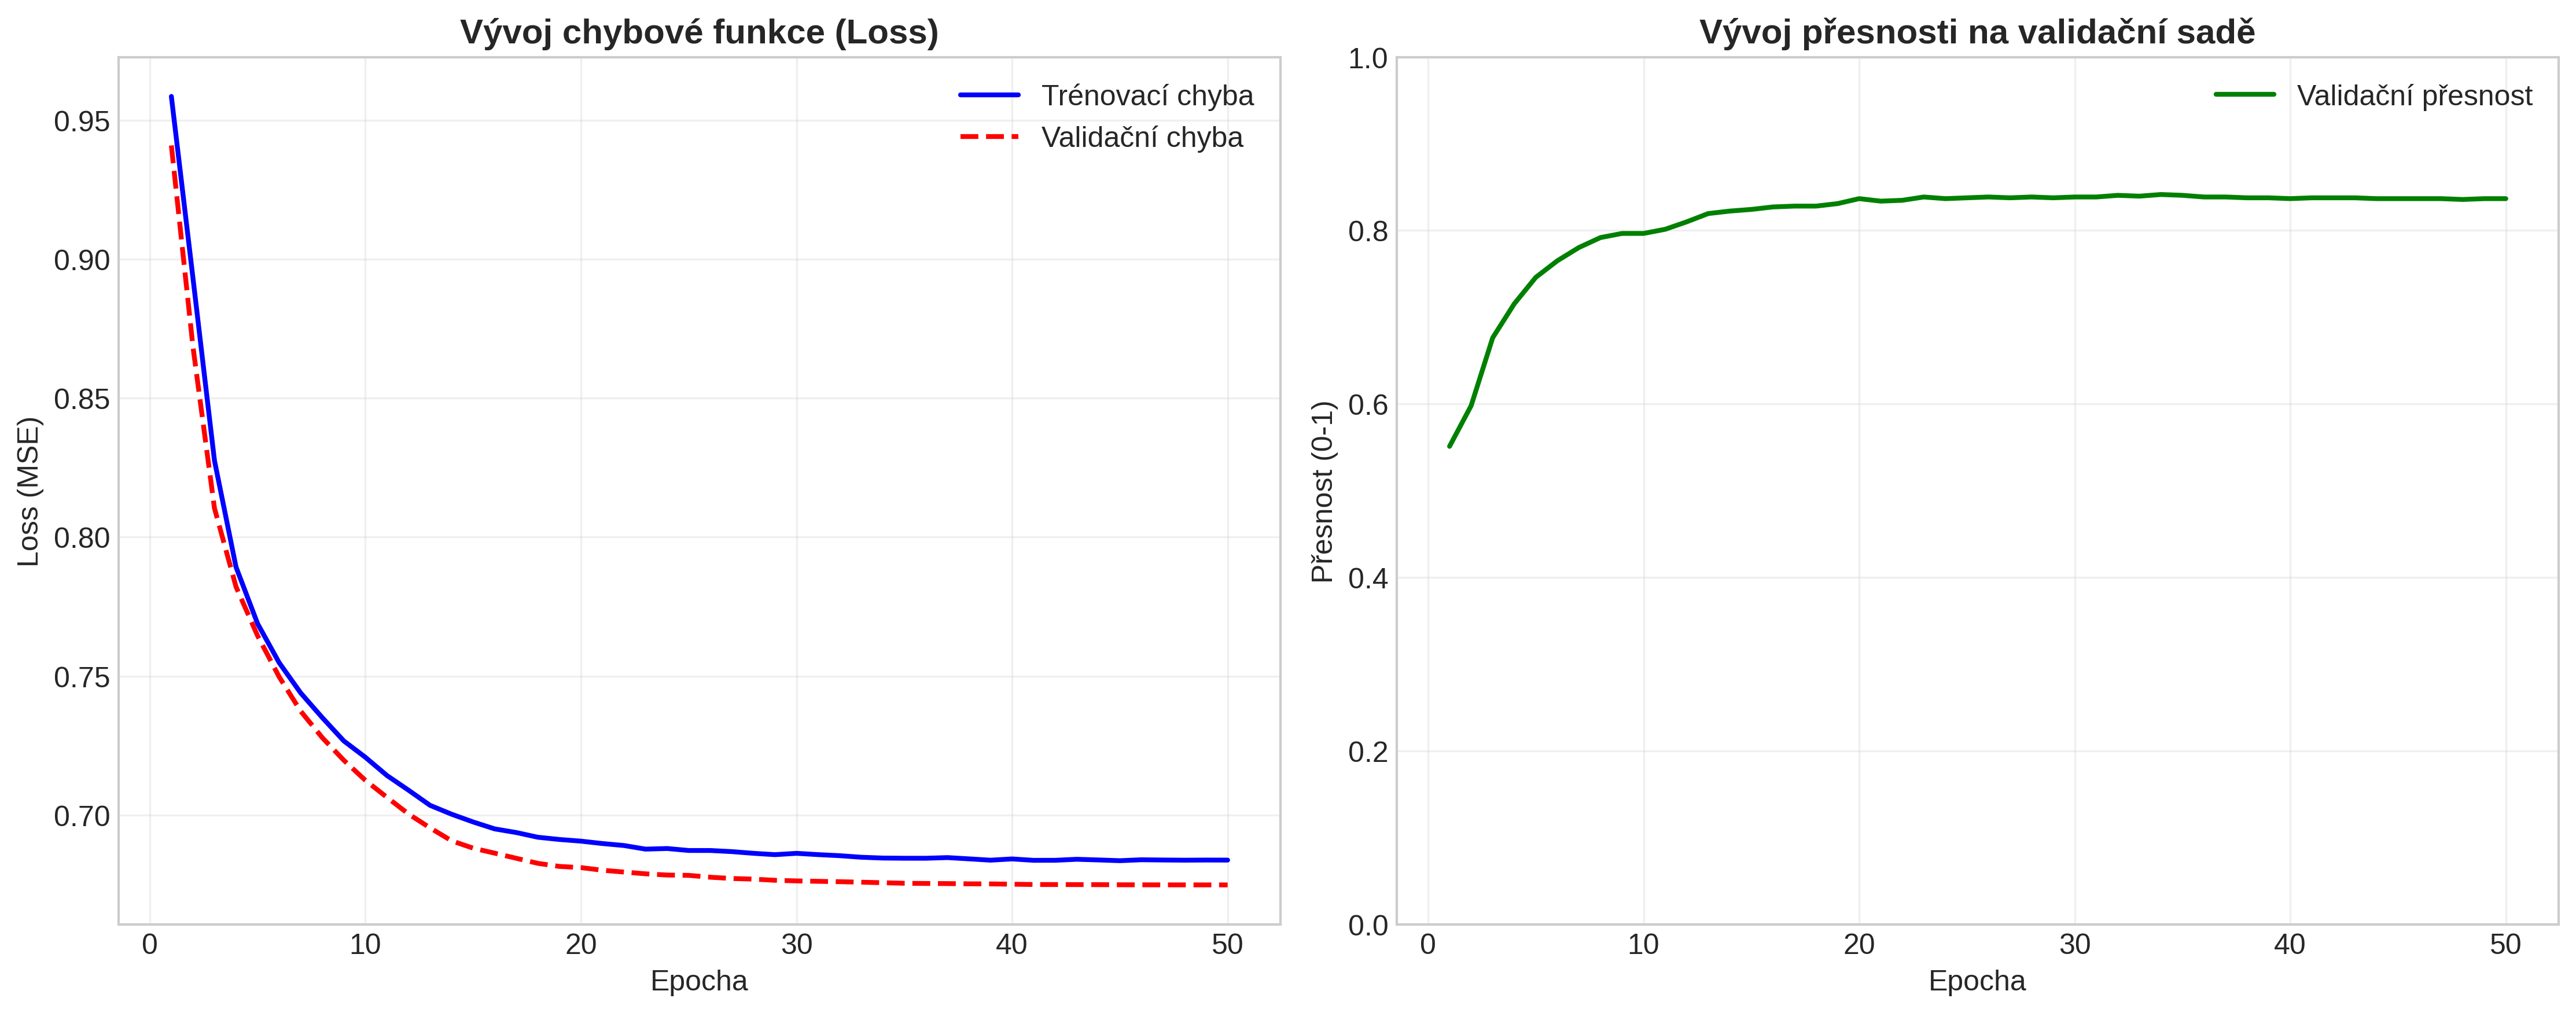

📊 Grafy metrik uloženy: ./results/evaluation_metrics.png


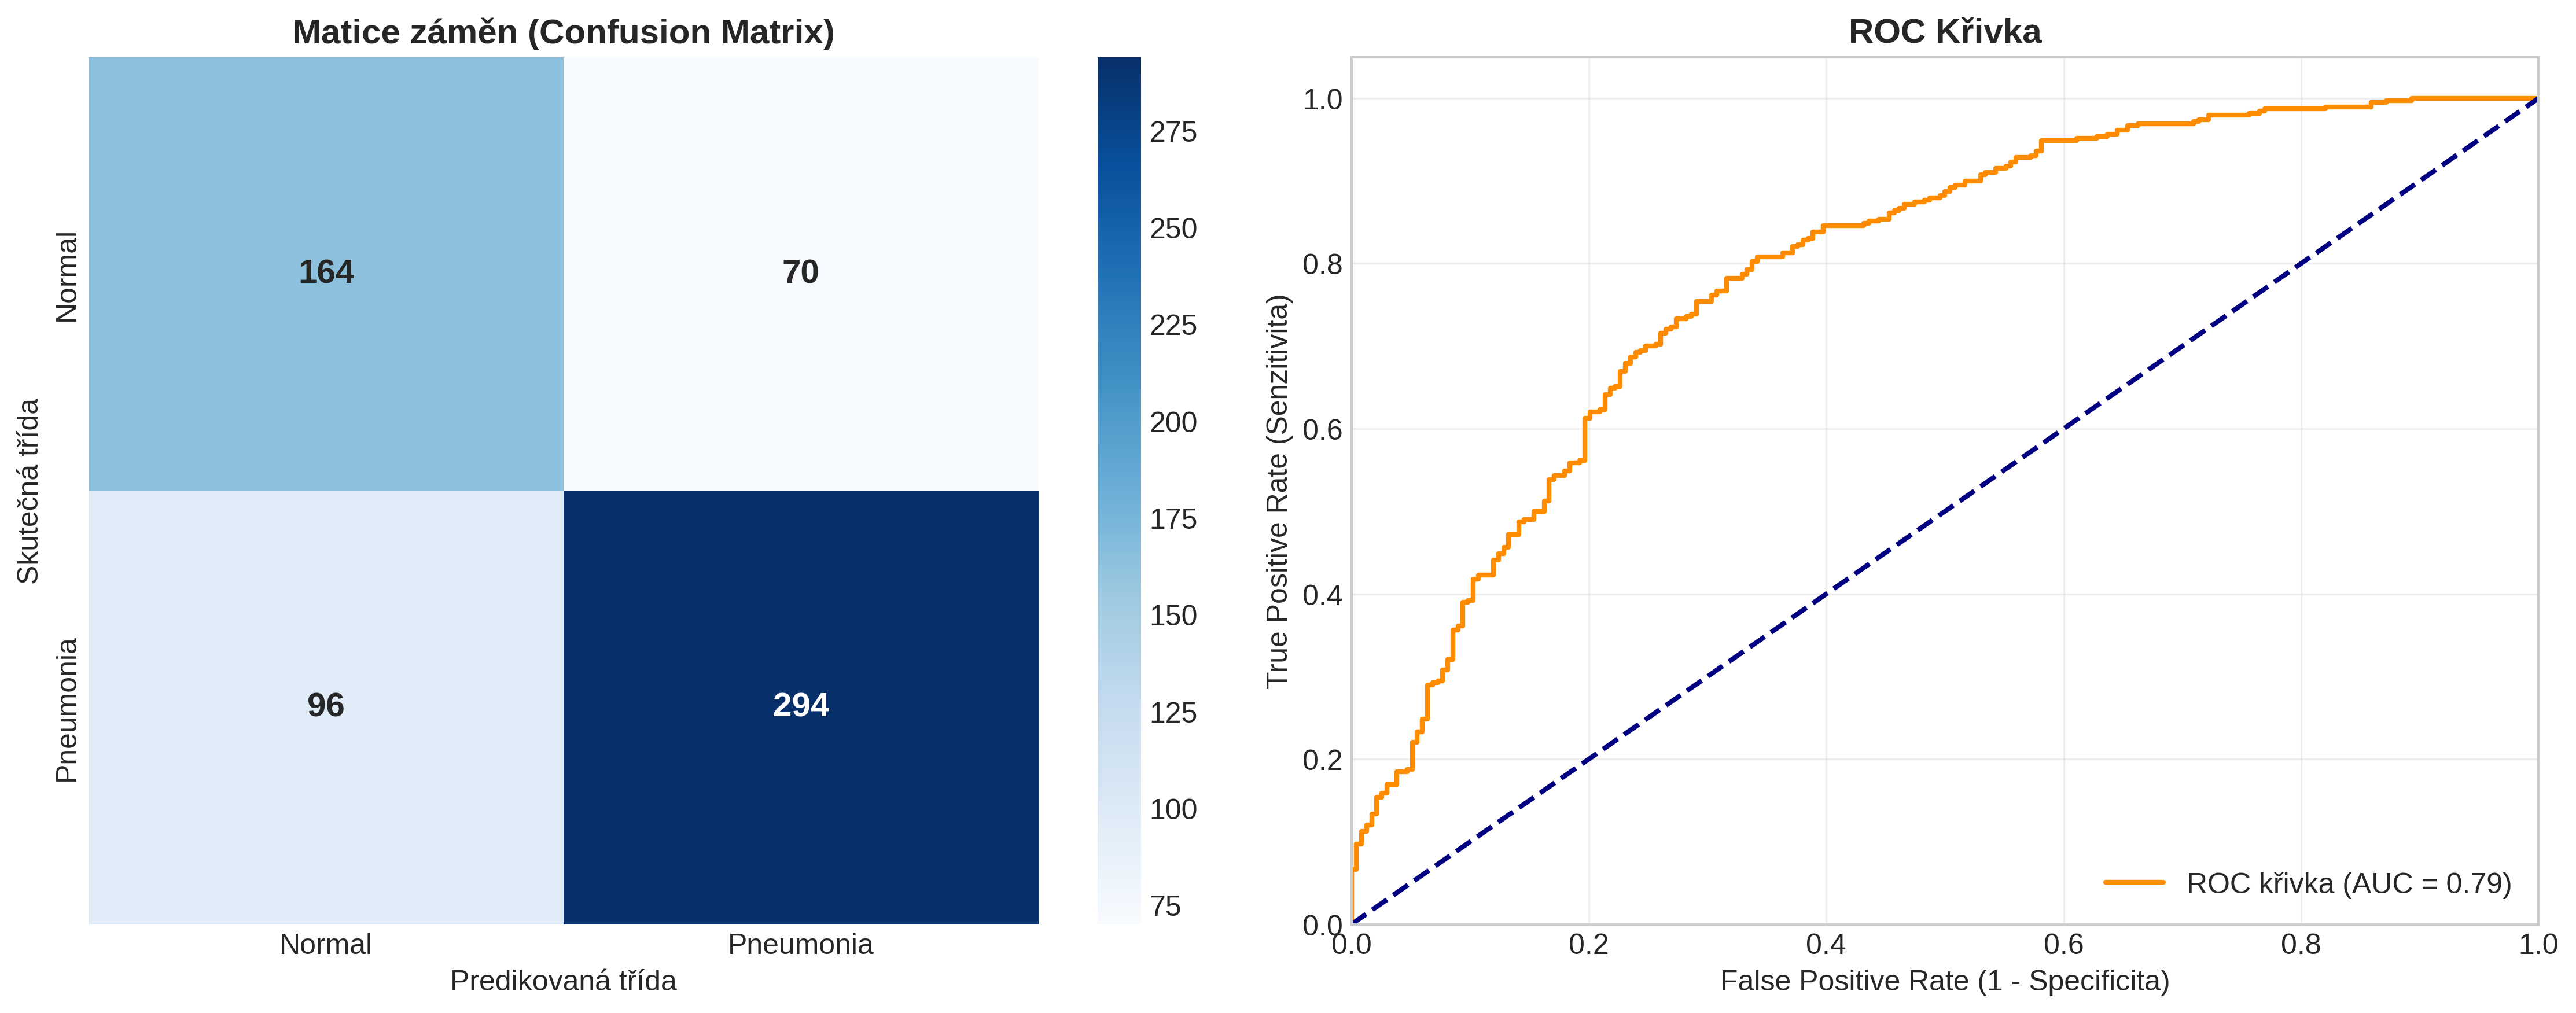


📝 Data pro tabulku výsledků v SOČ:
-----------------------------------
Počet testovacích snímků: 624
TP (Správně Pneumonie):   294
TN (Správně Zdraví):      164
FP (Falešný poplach):     70
FN (Přehlédnutá nemoc):   96
-----------------------------------
Senzitivita (Recall):     0.7538
Specificita:              0.7009
AUC:                      0.7923


: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np
import os

# Nastavení profesionálního vzhledu grafů
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300}) # 300 DPI pro tiskovou kvalitu

def plot_training_history(history, save_dir):
    """
    Vykreslí vývoj chyby (Loss) a přesnosti (Accuracy) během tréninku.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Graf Chyby (Loss)
    ax1.plot(epochs, history['train_loss'], 'b-', label='Trénovací chyba', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r--', label='Validační chyba', linewidth=2)
    ax1.set_title('Vývoj chybové funkce (Loss)', fontweight='bold')
    ax1.set_xlabel('Epocha')
    ax1.set_ylabel('Loss (MSE)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Graf Přesnosti (Accuracy)
    ax2.plot(epochs, history['val_acc'], 'g-', label='Validační přesnost', linewidth=2)
    ax2.set_title('Vývoj přesnosti na validační sadě', fontweight='bold')
    ax2.set_xlabel('Epocha')
    ax2.set_ylabel('Přesnost (0-1)')
    ax2.set_ylim(0, 1.0)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, "training_history.png")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"📈 Graf tréninku uložen: {save_path}")
    plt.show()

def plot_evaluation_metrics(y_true, y_pred, y_probs, save_dir):
    """
    Vykreslí Matici záměn a ROC křivku.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Matice záměn (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'],
                annot_kws={"size": 14, "weight": "bold"})
    ax1.set_title('Matice záměn (Confusion Matrix)', fontweight='bold')
    ax1.set_ylabel('Skutečná třída')
    ax1.set_xlabel('Predikovaná třída')
    
    # 2. ROC Křivka
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC křivka (AUC = {roc_auc:.2f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate (1 - Specificita)')
    ax2.set_ylabel('True Positive Rate (Senzitivita)')
    ax2.set_title('ROC Křivka', fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, "evaluation_metrics.png")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"📊 Grafy metrik uloženy: {save_path}")
    plt.show()

# --- Spuštění vizualizace ---

# Používáme proměnné z předchozích kroků:
# history (z kroku 5)
# y_data['test'] (z kroku 4/5 - skutečné hodnoty)
# test_preds (z kroku 5 - predikované 0/1)
# test_probs (z kroku 5 - pravděpodobnosti)

print(f"=== VIZUALIZACE VÝSLEDKŮ PRO SOČ ===")
plot_training_history(history, CFG.output_dir)
plot_evaluation_metrics(y_data['test'], test_preds, test_probs, CFG.output_dir)

# Bonus: Výpis finálních čísel pro text práce
cm = confusion_matrix(y_data['test'], test_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\n📝 Data pro tabulku výsledků v SOČ:")
print(f"-----------------------------------")
print(f"Počet testovacích snímků: {len(y_data['test'])}")
print(f"TP (Správně Pneumonie):   {tp}")
print(f"TN (Správně Zdraví):      {tn}")
print(f"FP (Falešný poplach):     {fp}")
print(f"FN (Přehlédnutá nemoc):   {fn}")
print(f"-----------------------------------")
print(f"Senzitivita (Recall):     {sensitivity:.4f}")
print(f"Specificita:              {specificity:.4f}")
print(f"AUC:                      {roc_auc_score(y_data['test'], test_probs):.4f}")

🔬 INTERPRETABILITY ANALYSIS FOR CLINICAL ADOPTION

📍 1. GradCAM Analysis...
🔥 GradCAM saved to ./results/interpretability/gradcam.png


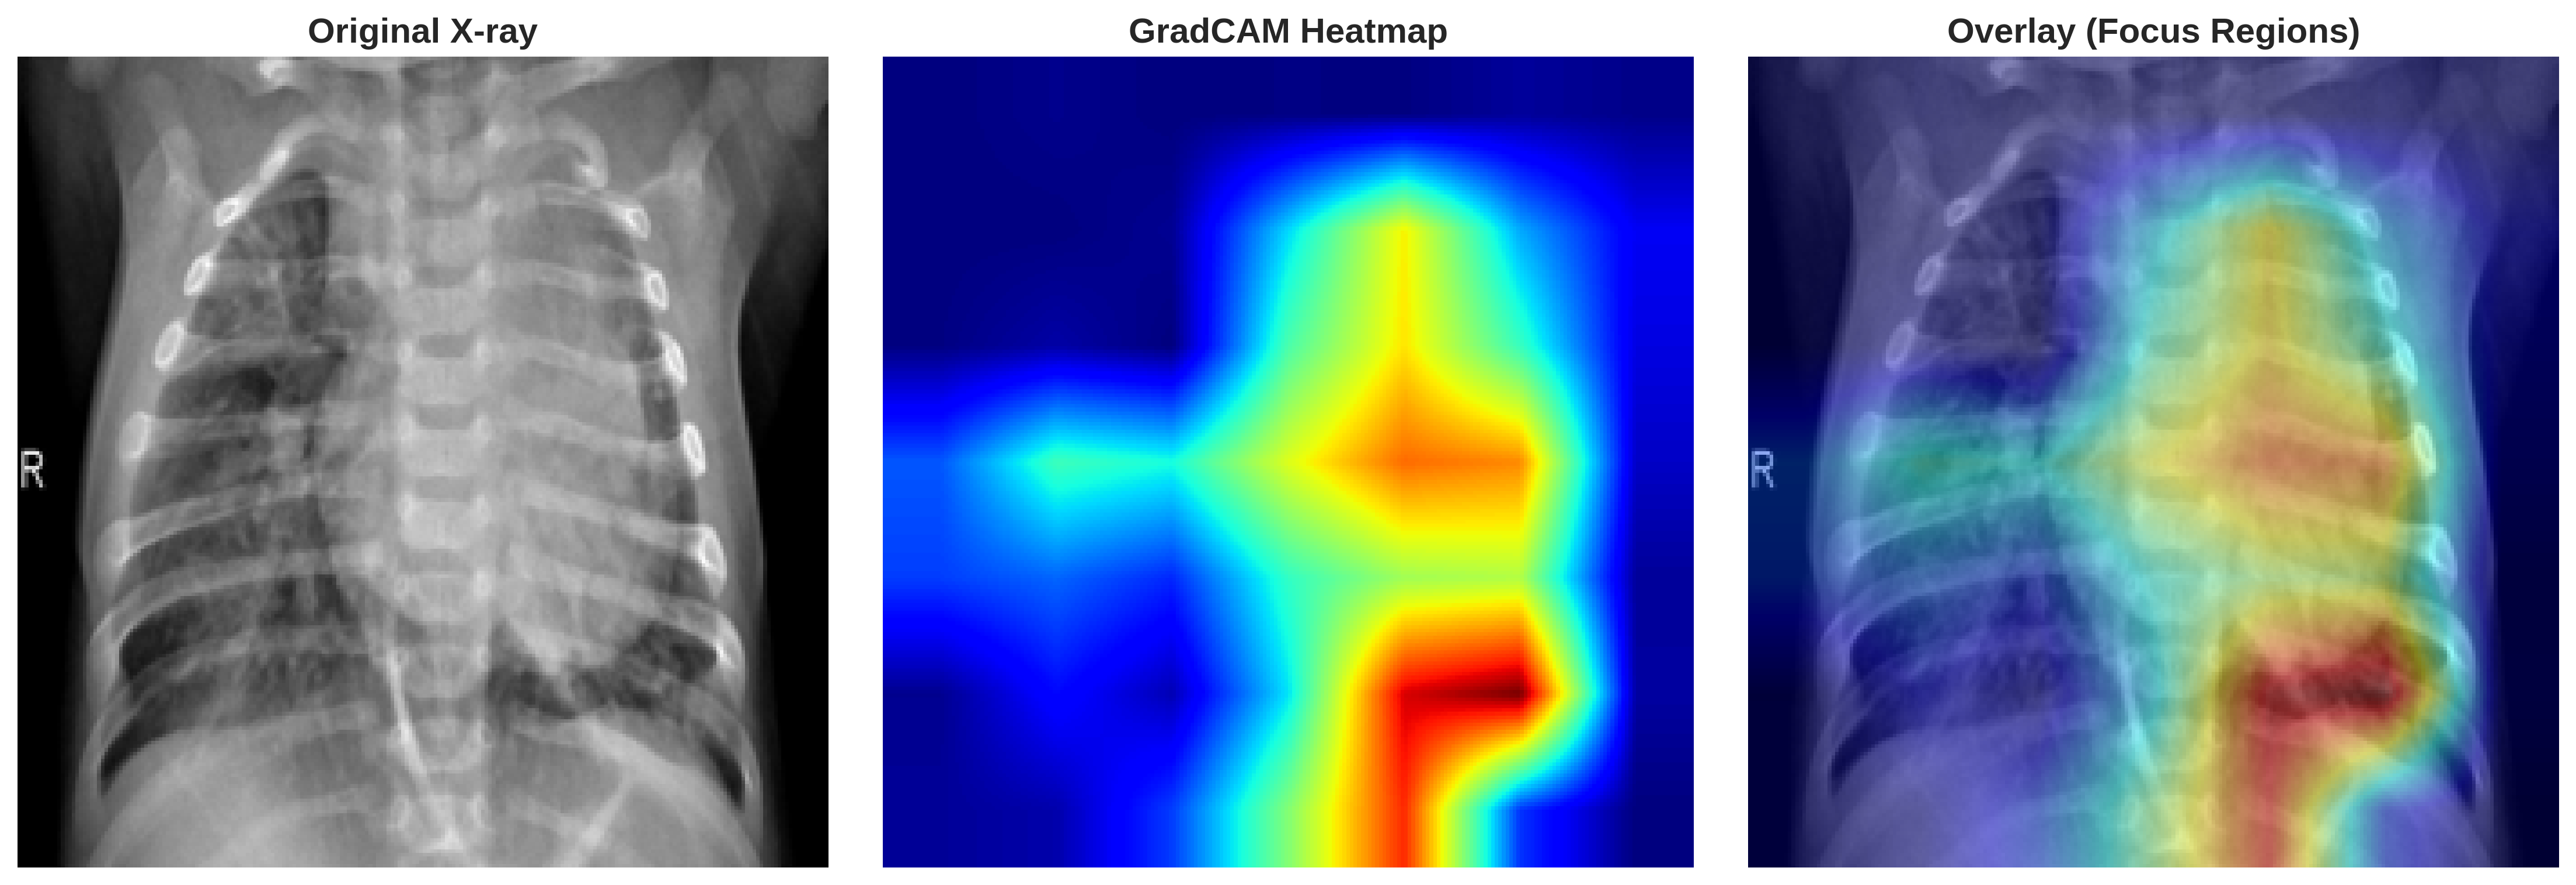


⚛️ 2. Quantum Qubit Importance...


/tmp/ipython-input-1251722844.py:174: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1251722844.py:176: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Liberation Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


⚛️ Qubit importance saved to ./results/interpretability/qubit_importance.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


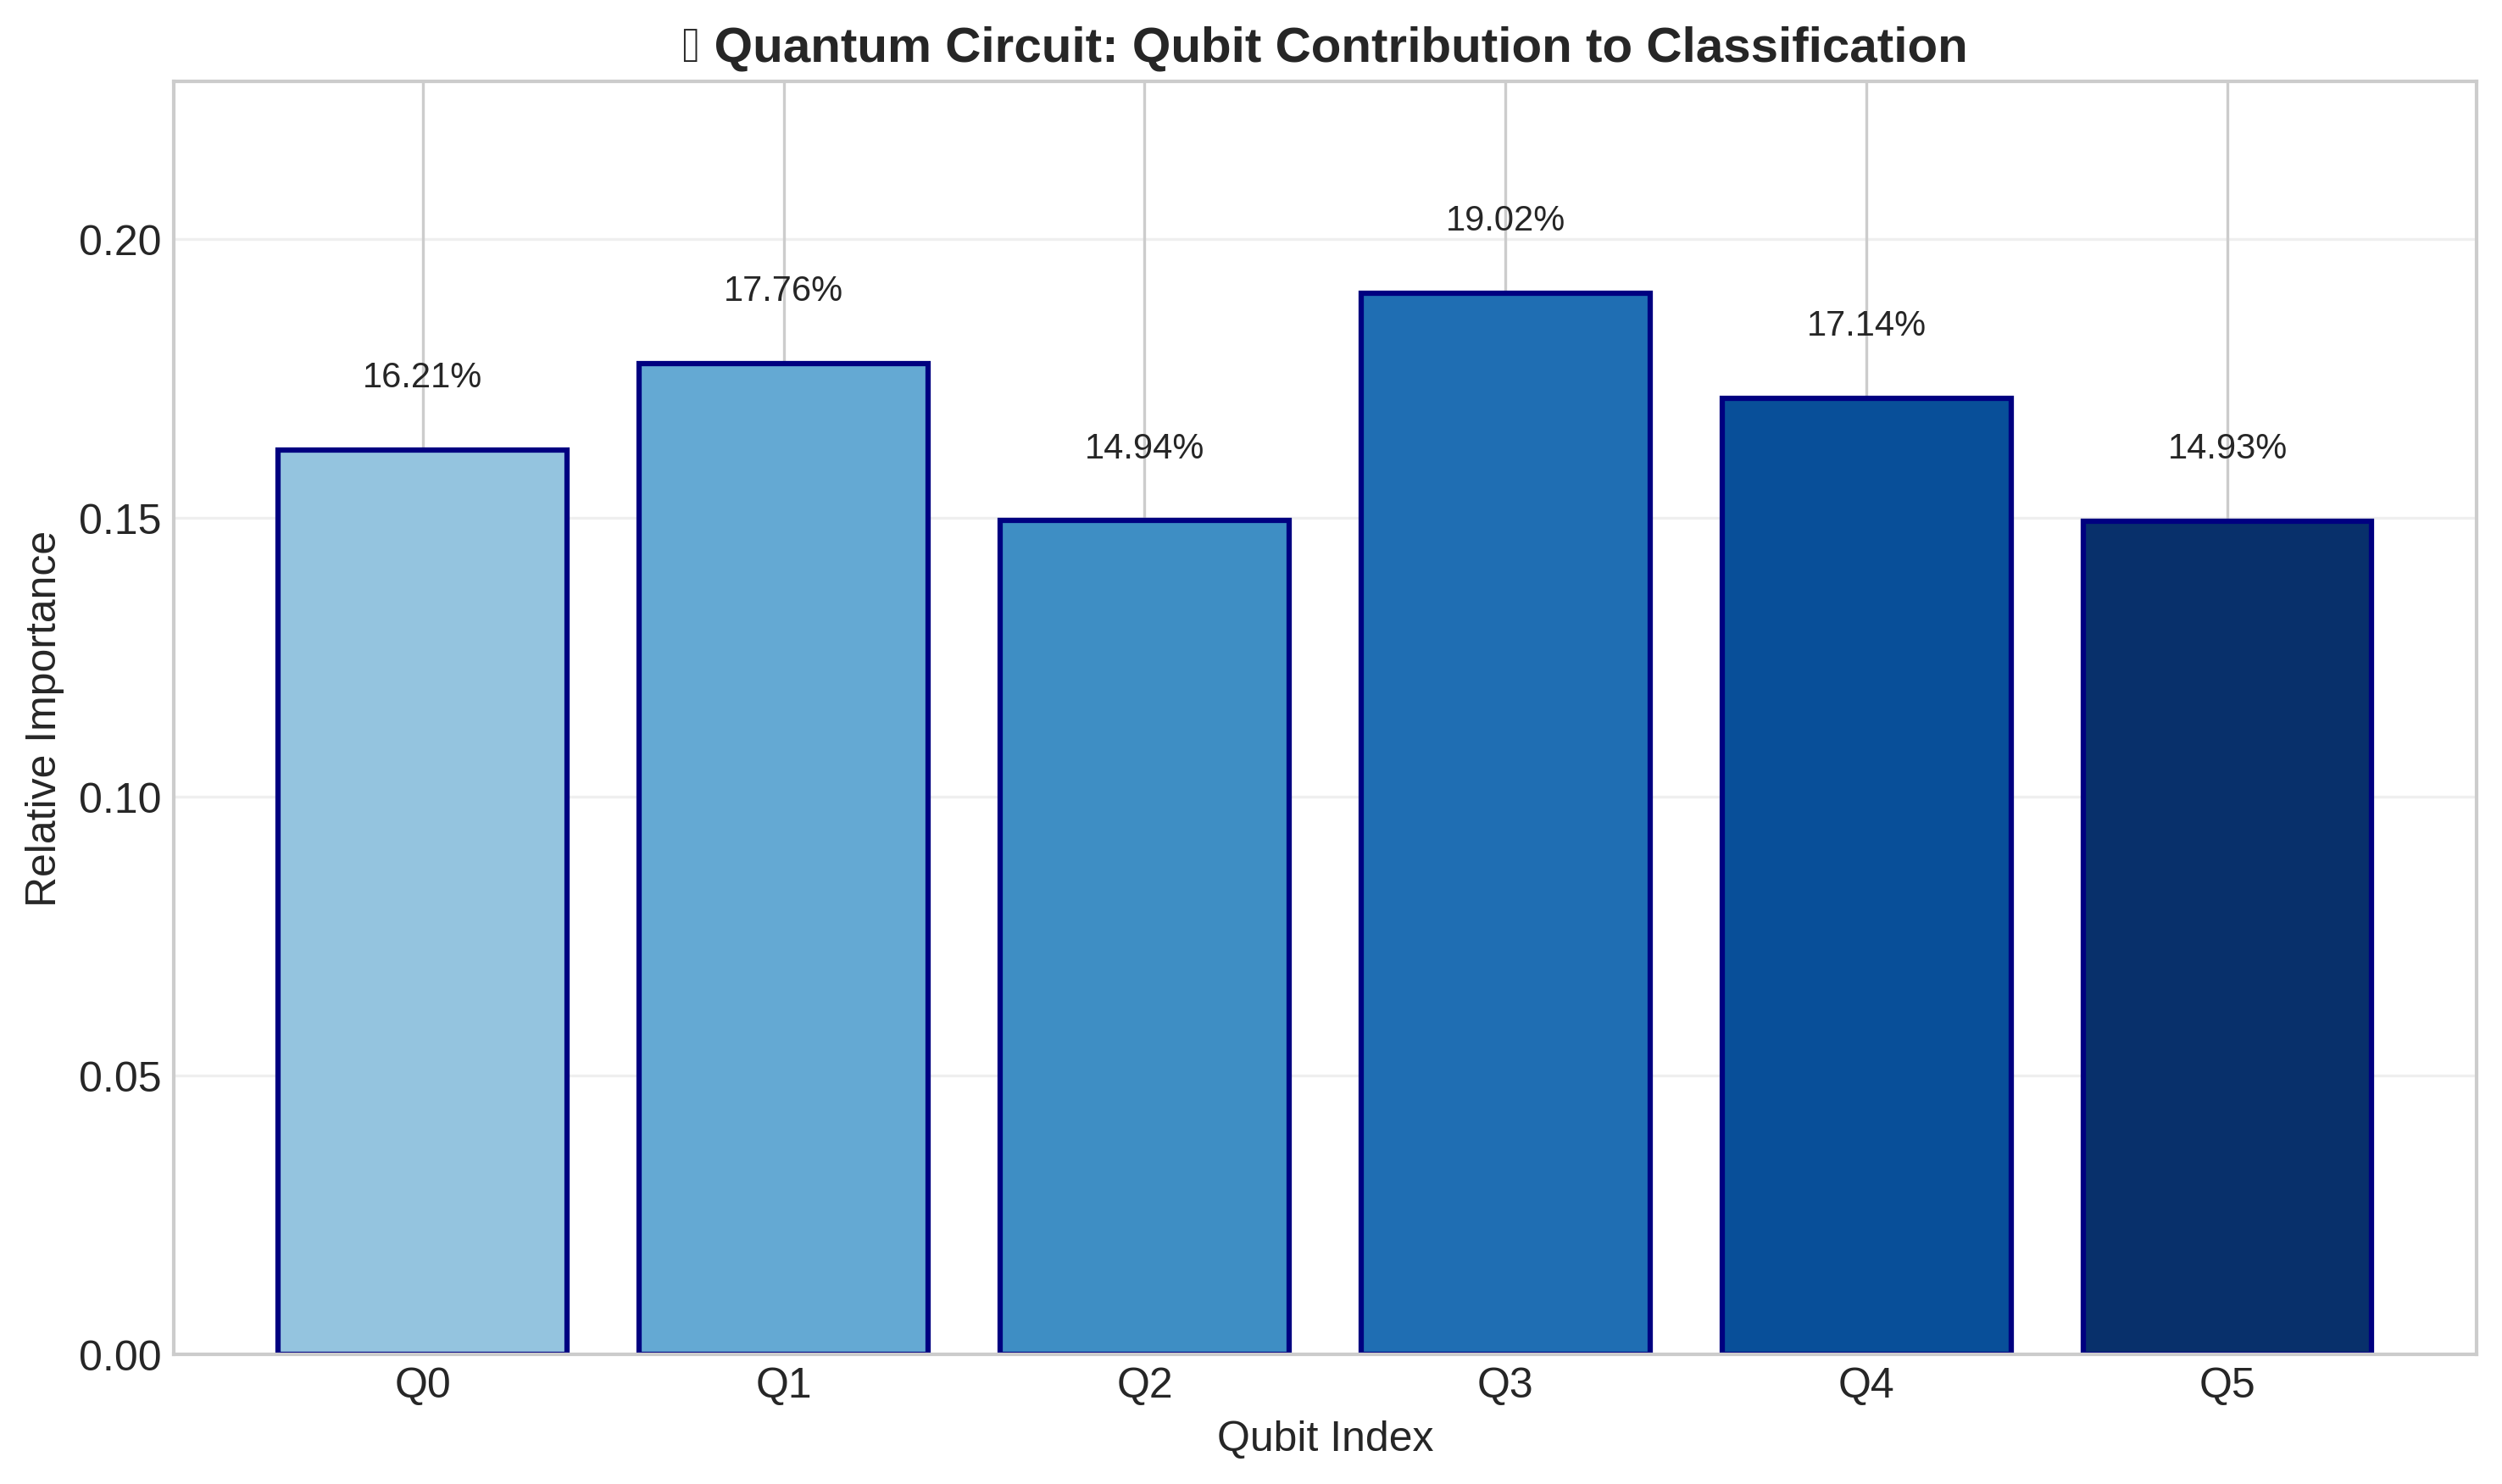


📊 3. Sensitivity Analysis...
📊 Sensitivity analysis saved to ./results/interpretability/sensitivity.png


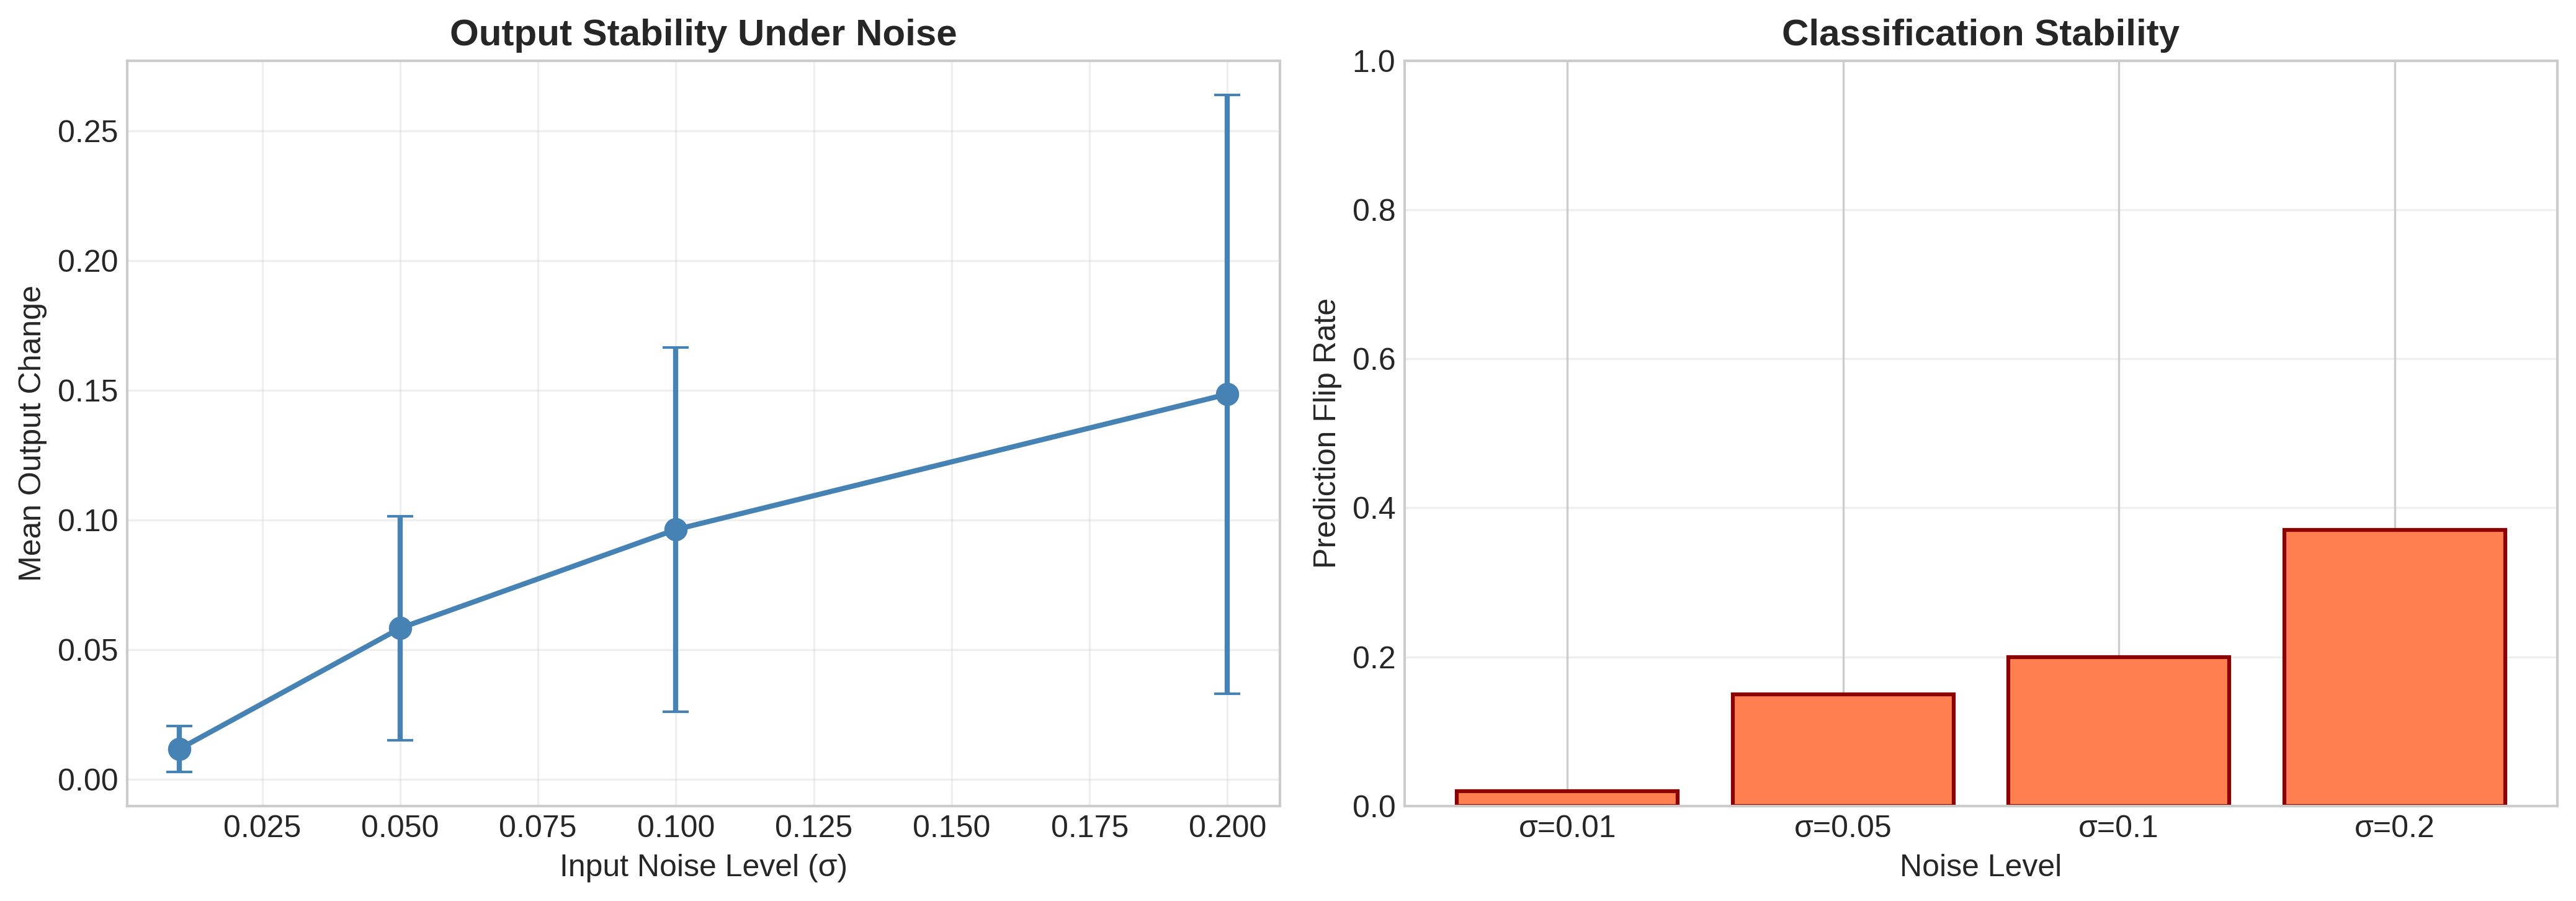


📈 4. PCA Component Analysis...
📈 PCA importance saved to ./results/interpretability/pca_importance.png


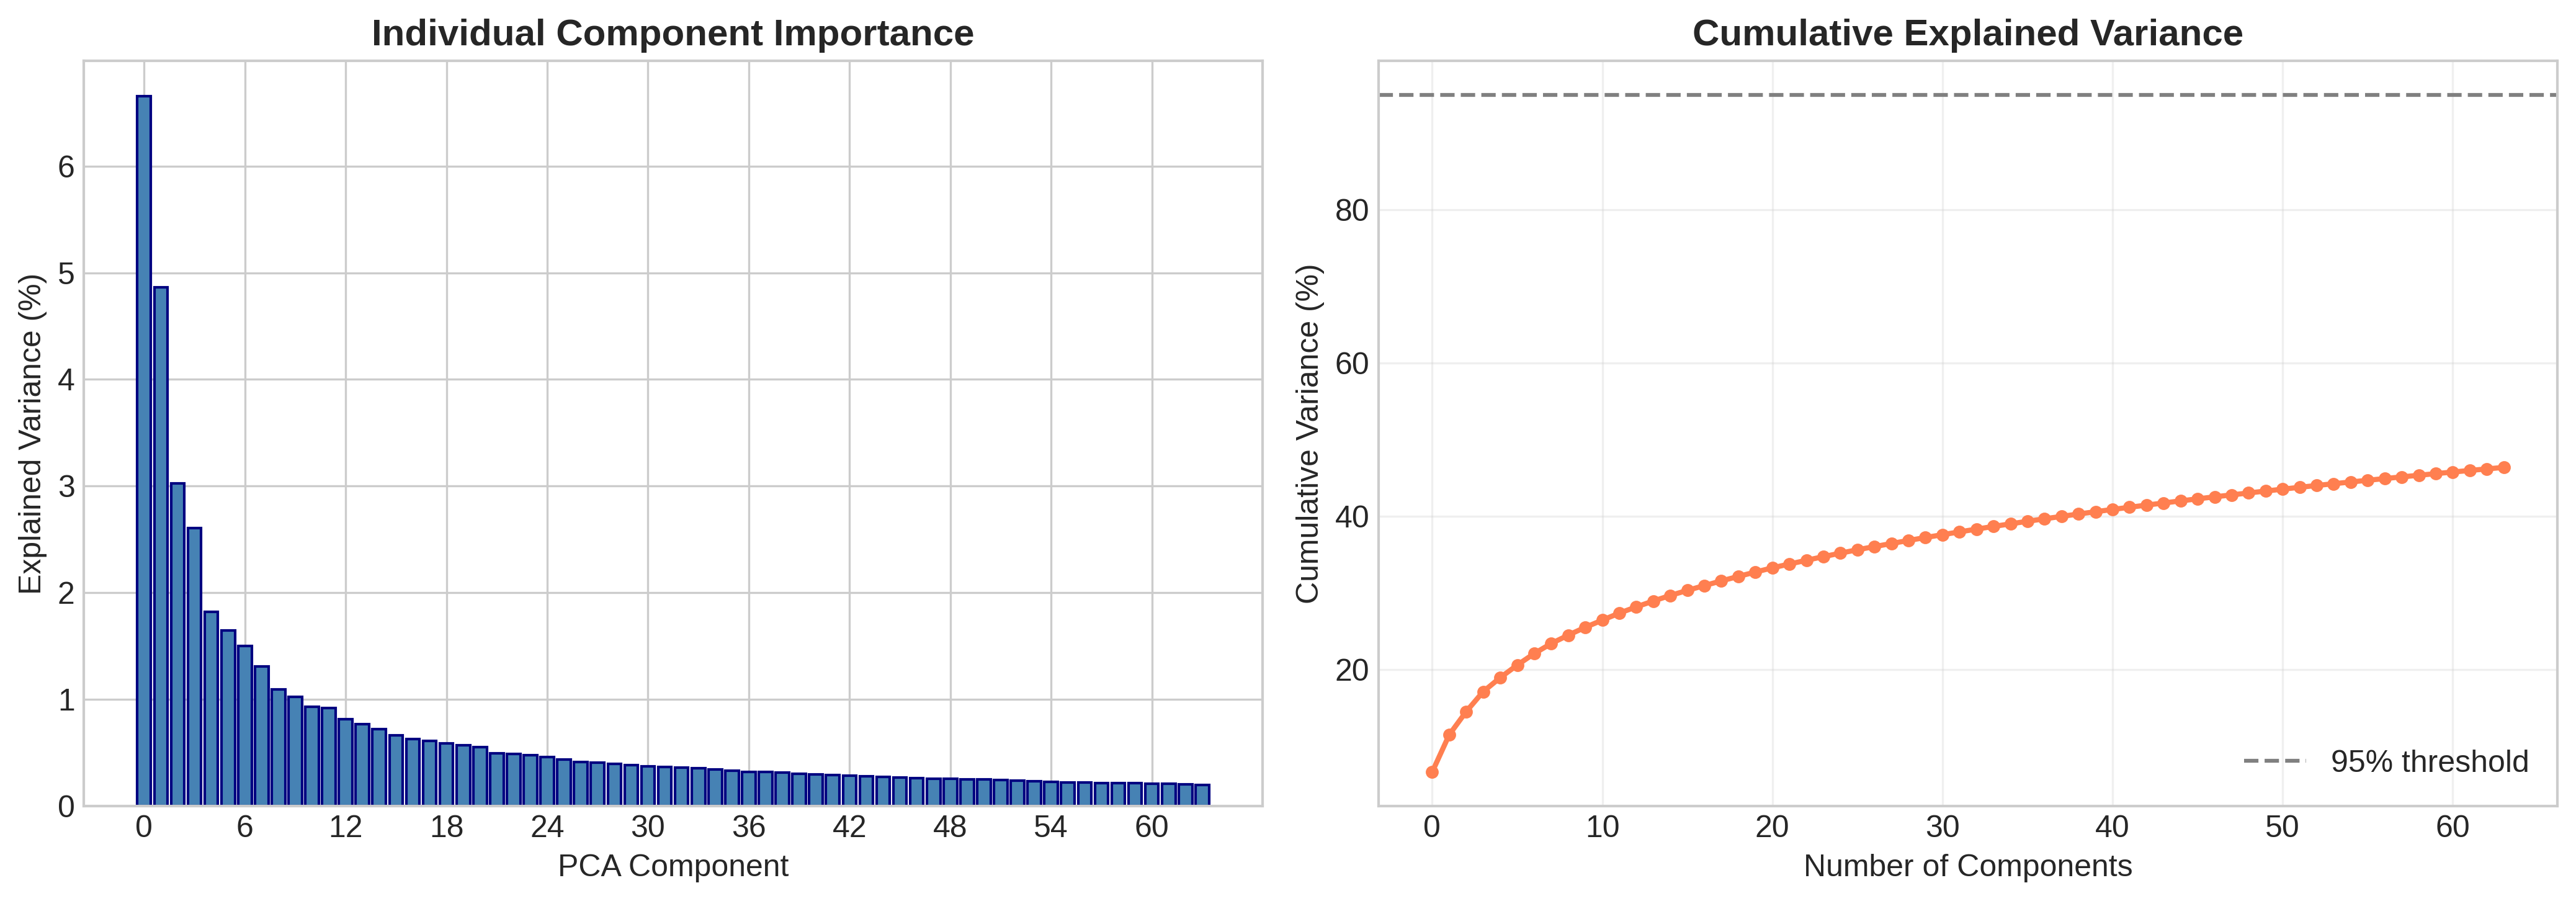


✅ All interpretability results saved to: ./results/interpretability


: 

In [ ]:
# =============================================================================
# 🔬 INTERPRETABILITY FOR MEDICAL DOMAIN
# =============================================================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, transforms
from PIL import Image
import cv2
import os

# -----------------------------------------------------------------------------
# 1. GradCAM - Where does the CNN backbone look?
# -----------------------------------------------------------------------------

class GradCAM:
    """
    GradCAM for ResNet50 feature extractor.
    Shows which regions of the X-ray the model focuses on.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx=None):
        """Generate GradCAM heatmap."""
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        # Global average pooling of gradients
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        
        # Weighted combination of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        
        # Normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.squeeze().cpu().numpy()


def visualize_gradcam(image_path, model, save_path=None):
    """
    Generate and display GradCAM visualization for a chest X-ray.
    """
    # Load and preprocess image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).cuda()
    
    # Get GradCAM for layer4 (last convolutional block)
    gradcam = GradCAM(model, model.layer4[-1])
    heatmap = gradcam.generate(input_tensor)
    
    # Resize heatmap to match image
    heatmap = cv2.resize(heatmap, (224, 224))
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    img_array = np.array(img.resize((224, 224)))
    axes[0].imshow(img_array)
    axes[0].set_title('Original X-ray', fontweight='bold')
    axes[0].axis('off')
    
    # Heatmap
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontweight='bold')
    axes[1].axis('off')
    
    # Overlay
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_array, 0.6, heatmap_colored, 0.4, 0)
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay (Focus Regions)', fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"🔥 GradCAM saved to {save_path}")
    plt.show()


# -----------------------------------------------------------------------------
# 2. QUANTUM FEATURE IMPORTANCE - Which qubits matter most?
# -----------------------------------------------------------------------------

def quantum_feature_importance(qnode, params, X_test, y_test, config, n_samples=100):
    """
    Compute feature importance by measuring output sensitivity to each qubit.
    Uses parameter perturbation analysis.
    """
    n_qubits = config.n_qubits
    n_layers = config.n_layers
    
    # Baseline predictions
    baseline_preds = np.array([qnode(x, params) for x in X_test[:n_samples]])
    
    # Importance per qubit (averaged across layers)
    qubit_importance = np.zeros(n_qubits)
    
    for q in range(n_qubits):
        perturbed_params = params.copy()
        
        # Zero out all parameters for this qubit across all layers
        for l in range(n_layers):
            perturbed_params[l, q, :] = 0.0
        
        # Get perturbed predictions
        perturbed_preds = np.array([qnode(x, perturbed_params) for x in X_test[:n_samples]])
        
        # Importance = mean absolute change in output
        qubit_importance[q] = np.mean(np.abs(baseline_preds - perturbed_preds))
    
    # Normalize
    qubit_importance = qubit_importance / (qubit_importance.sum() + 1e-8)
    
    return qubit_importance


def plot_qubit_importance(importance, save_path=None):
    """Visualize which qubits contribute most to predictions."""
    n_qubits = len(importance)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.Blues(np.linspace(0.4, 1.0, n_qubits))
    bars = ax.bar(range(n_qubits), importance, color=colors, edgecolor='navy', linewidth=1.5)
    
    ax.set_xlabel('Qubit Index', fontsize=12)
    ax.set_ylabel('Relative Importance', fontsize=12)
    ax.set_title('🔮 Quantum Circuit: Qubit Contribution to Classification', fontweight='bold', fontsize=14)
    ax.set_xticks(range(n_qubits))
    ax.set_xticklabels([f'Q{i}' for i in range(n_qubits)])
    
    # Add value labels on bars
    for bar, val in zip(bars, importance):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.2%}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylim(0, max(importance) * 1.2)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"⚛️ Qubit importance saved to {save_path}")
    plt.show()


# -----------------------------------------------------------------------------
# 3. SENSITIVITY ANALYSIS - How stable are predictions?
# -----------------------------------------------------------------------------

def sensitivity_analysis(qnode, params, X_test, config, noise_levels=[0.01, 0.05, 0.1, 0.2]):
    """
    Test model robustness by adding noise to input features.
    Important for clinical reliability assessment.
    """
    n_samples = min(100, len(X_test))
    X_subset = X_test[:n_samples]
    
    # Baseline predictions
    baseline_preds = np.array([qnode(x, params) for x in X_subset])
    
    results = {'noise_level': [], 'mean_change': [], 'std_change': [], 'flip_rate': []}
    
    for noise in noise_levels:
        changes = []
        flips = 0
        
        for i, x in enumerate(X_subset):
            # Add Gaussian noise
            noisy_x = x + np.random.normal(0, noise, size=x.shape)
            noisy_x = noisy_x / (np.linalg.norm(noisy_x) + 1e-8)  # Re-normalize
            
            noisy_pred = qnode(noisy_x, params)
            change = abs(noisy_pred - baseline_preds[i])
            changes.append(change)
            
            # Check if prediction flips
            if (baseline_preds[i] > 0) != (noisy_pred > 0):
                flips += 1
        
        results['noise_level'].append(noise)
        results['mean_change'].append(np.mean(changes))
        results['std_change'].append(np.std(changes))
        results['flip_rate'].append(flips / n_samples)
    
    return results


def plot_sensitivity(results, save_path=None):
    """Visualize model sensitivity to input perturbations."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Output change vs noise
    ax1.errorbar(results['noise_level'], results['mean_change'], 
                 yerr=results['std_change'], marker='o', capsize=5,
                 color='steelblue', linewidth=2, markersize=8)
    ax1.set_xlabel('Input Noise Level (σ)', fontsize=12)
    ax1.set_ylabel('Mean Output Change', fontsize=12)
    ax1.set_title('Output Stability Under Noise', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Prediction flip rate
    ax2.bar(range(len(results['noise_level'])), results['flip_rate'], 
            color='coral', edgecolor='darkred', linewidth=1.5)
    ax2.set_xlabel('Noise Level', fontsize=12)
    ax2.set_ylabel('Prediction Flip Rate', fontsize=12)
    ax2.set_title('Classification Stability', fontweight='bold')
    ax2.set_xticks(range(len(results['noise_level'])))
    ax2.set_xticklabels([f'σ={n}' for n in results['noise_level']])
    ax2.set_ylim(0, 1)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Sensitivity analysis saved to {save_path}")
    plt.show()


# -----------------------------------------------------------------------------
# 4. PCA FEATURE IMPORTANCE - Which ResNet features matter?
# -----------------------------------------------------------------------------

def pca_feature_importance(config):
    """
    Analyze which PCA components (from ResNet features) are most important.
    """
    import joblib
    
    pipeline_path = os.path.join(config.output_dir, "preprocessing_pipeline.joblib")
    pipeline = joblib.load(pipeline_path)
    
    # Get PCA from pipeline
    pca = pipeline.named_steps['reducer']
    
    # Explained variance per component
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    
    return explained_var, cumulative_var


def plot_pca_importance(explained_var, cumulative_var, save_path=None):
    """Visualize PCA component importance."""
    n_components = len(explained_var)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Individual variance
    ax1.bar(range(n_components), explained_var * 100, color='steelblue', edgecolor='navy')
    ax1.set_xlabel('PCA Component', fontsize=12)
    ax1.set_ylabel('Explained Variance (%)', fontsize=12)
    ax1.set_title('Individual Component Importance', fontweight='bold')
    ax1.set_xticks(range(0, n_components, max(1, n_components//10)))
    
    # Cumulative variance
    ax2.plot(range(n_components), cumulative_var * 100, 'o-', color='coral', linewidth=2, markersize=4)
    ax2.axhline(y=95, color='gray', linestyle='--', label='95% threshold')
    ax2.set_xlabel('Number of Components', fontsize=12)
    ax2.set_ylabel('Cumulative Variance (%)', fontsize=12)
    ax2.set_title('Cumulative Explained Variance', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📈 PCA importance saved to {save_path}")
    plt.show()


# -----------------------------------------------------------------------------
# 5. RUN ALL INTERPRETABILITY ANALYSES
# -----------------------------------------------------------------------------

def run_interpretability_suite(config, qnode, best_params, X_data, y_data, sample_image_path=None):
    """
    Execute all interpretability analyses and save results.
    """
    print("=" * 60)
    print("🔬 INTERPRETABILITY ANALYSIS FOR CLINICAL ADOPTION")
    print("=" * 60)
    
    save_dir = os.path.join(config.output_dir, "interpretability")
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. GradCAM (if sample image provided)
    if sample_image_path and os.path.exists(sample_image_path):
        print("\n📍 1. GradCAM Analysis...")
        # Load ResNet for GradCAM
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        resnet.eval().cuda()
        visualize_gradcam(sample_image_path, resnet, 
                         save_path=os.path.join(save_dir, "gradcam.png"))
    else:
        print("\n⚠️ 1. GradCAM skipped (no sample image provided)")
    
    # 2. Quantum Feature Importance
    print("\n⚛️ 2. Quantum Qubit Importance...")
    qubit_imp = quantum_feature_importance(
        qnode, best_params, X_data['test'], y_data['test'], config, n_samples=50
    )
    plot_qubit_importance(qubit_imp, 
                         save_path=os.path.join(save_dir, "qubit_importance.png"))
    
    # 3. Sensitivity Analysis
    print("\n📊 3. Sensitivity Analysis...")
    sensitivity = sensitivity_analysis(qnode, best_params, X_data['test'], config)
    plot_sensitivity(sensitivity, 
                    save_path=os.path.join(save_dir, "sensitivity.png"))
    
    # 4. PCA Feature Importance
    print("\n📈 4. PCA Component Analysis...")
    try:
        exp_var, cum_var = pca_feature_importance(config)
        plot_pca_importance(exp_var, cum_var, 
                           save_path=os.path.join(save_dir, "pca_importance.png"))
    except Exception as e:
        print(f"   ⚠️ PCA analysis skipped: {e}")
    
    print("\n" + "=" * 60)
    print(f"✅ All interpretability results saved to: {save_dir}")
    print("=" * 60)
    
    return {
        'qubit_importance': qubit_imp,
        'sensitivity': sensitivity
    }


# =============================================================================
# 🚀 EXECUTE INTERPRETABILITY SUITE
# =============================================================================

# Find a sample pneumonia image for GradCAM
import pandas as pd
meta_df = pd.read_csv(os.path.join(CFG.output_dir, "metadata.csv"))
pneumonia_samples = meta_df[(meta_df['split'] == 'test') & (meta_df['classname'] == 'PNEUMONIA')]
sample_img = pneumonia_samples.iloc[0]['original_path'] if len(pneumonia_samples) > 0 else None

# Run full suite
interpretability_results = run_interpretability_suite(
    config=CFG,
    qnode=qnode,
    best_params=best_params,
    X_data=X_data,
    y_data=y_data,
    sample_image_path=sample_img
)
